# FashionVision: Clothing Image Classification Project

## 🧵 Project Overview

FashionVision is a computer vision project aimed at automatically classifying fashion product images into clothing categories such as:

- tops  
- longsleeves  
- jeans  
- dresses  
- skirts  
- coats  
- boots  
- tshirts  
- bodysuits  
- sportshorts  

The dataset is created by scraping real product images and metadata from Zalando, which makes the project realistic and close to e-commerce applications.

The model will be used to explore how accurately machine learning can categorize clothing images.

## Motivation

Large fashion stores and online retailers upload thousands of products every week.
Each of these must be labeled and categorized correctly for users to:

- search efficiently

- filter products

- get relevant recommendations

- enjoy a smooth shopping experience

Manual labeling is slow, expensive, and sometimes inconsistent.

From a learning perspective, this project allows me to:

- practice web scraping

- preprocess and prepare real-world image data

- experiment with CNNs and transfer learning

- evaluate robustness under diverse photography conditions

- work with a real stakeholder (e.g., a retail employee)

The project is both practically useful and technically valuable for my development.

## Data Collection

To build a realistic and high-quality dataset for this project, I collected clothing product images directly from **Zalando**. The goal was to gather real-world examples across multiple categories so the model could learn from authentic e-commerce data rather than artificial samples.

### First Approach: Full Product Scraper

In the first stage of data collection, I scraped **complete product pages** from Zalando across several clothing categories.  
These categories were:

- shirts  
- boots  
- skirts  
- dresses  
- jeans  
- jackets  
- sneakers  

#### How the scraping was done

To build this dataset, I used **Selenium WebDriver** to automate the browser:

- I loaded each category page and scrolled multiple times to trigger lazy-loaded product tiles  
- I extracted all product links from the page using CSS selectors  
- I visited each product link individually to load the full product page  
- On each page, I scraped metadata such as the product title, brand, price, and color  
- I located the main product image, extracted its URL, and downloaded it  
- All image paths and metadata were stored in a CSV file for later use  

This approach provided a rich dataset with real product information, but the images were **inconsistent** because many included models, lifestyle shots, or zoomed-in details.

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import pandas as pd
import time
import os
import urllib.request

# CONFIG

CATEGORIES = {
    "shirts":   "https://www.zalando.nl/dameskleding-shirts/",
    "boots":    "https://www.zalando.nl/damesschoenen-laarzen/",
    "skirts":   "https://www.zalando.nl/dameskleding-rokken/",
    "dresses":  "https://www.zalando.nl/dameskleding-jurken/",
    "jeans":    "https://www.zalando.nl/dameskleding-jeans/",
    "jackets":  "https://www.zalando.nl/dameskleding-jassen/",
    "sneakers": "https://www.zalando.nl/damesschoenen-sneakers/",
}

MAX_PRODUCTS_PER_CATEGORY = 50  

IMAGES_ROOT = "images_zalando"
os.makedirs(IMAGES_ROOT, exist_ok=True)


def create_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")

    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--disable-infobars")
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    return driver


def scroll_page(driver, scroll_times=6, delay=2):
    
    last_height = driver.execute_script("return document.body.scrollHeight")
    for _ in range(scroll_times):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(delay)
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height


def get_product_links(driver, category_url):
    
    driver.get(category_url)
    time.sleep(3)

    scroll_page(driver)

    product_links = set()

    
    try:
        tiles = driver.find_elements(By.CSS_SELECTOR, '[data-testid="productTile"] a')
        for t in tiles:
            href = t.get_attribute("href")
            if href and href.endswith(".html"):
                product_links.add(href)
    except Exception:
        pass

  
    if len(product_links) == 0:
        try:
            anchors = driver.find_elements(By.CSS_SELECTOR, 'a[data-zalon-partner-product-id]')
            for a in anchors:
                href = a.get_attribute("href")
                if href and href.endswith(".html"):
                    product_links.add(href)
        except Exception:
            pass

   
    if len(product_links) == 0:
        anchors = driver.find_elements(By.TAG_NAME, "a")
        for a in anchors:
            href = a.get_attribute("href")
            if href and "zalando.nl" in href and href.endswith(".html") and "/dames" not in href:
                product_links.add(href)

    print(f"  -> Found {len(product_links)} product links")
    return list(product_links)



# SCRAPE PRODUCT DETAILS

def scrape_product_page(driver, url, label):

    driver.get(url)
    time.sleep(2)

    data = {
        "product_url": url,
        "label_category": label,   
    }

    # Title
    try:
        title_el = driver.find_element(By.CSS_SELECTOR, 'h1[data-testid="product-title"], h1')
        data["title"] = title_el.text.strip()
    except Exception:
        data["title"] = None

    # Brand
    try:
        brand_el = driver.find_element(By.CSS_SELECTOR, '[data-testid="product-brand"], span[data-testid="pdp-brand-name"], a[data-testid="pdp-brand-link"]')
        data["brand"] = brand_el.text.strip()
    except Exception:
        data["brand"] = None

    # Price
    try:
        price_el = driver.find_element(By.CSS_SELECTOR, '[data-testid="product-price"], p[data-testid="pdp-product-price"]')
        data["price"] = price_el.text.strip()
    except Exception:
        data["price"] = None

    # Color 
    color_text = None
    try:
        color_elements = driver.find_elements(By.XPATH, "//*[contains(text(), 'Kleur') or contains(text(), 'kleur')]")
        if color_elements:
            color_text = color_elements[0].text
    except Exception:
        pass
    data["color"] = color_text

    image_url = None
    try:
        img_candidates = driver.find_elements(By.CSS_SELECTOR, "img")
        for img in img_candidates:
            src = img.get_attribute("src")
            alt = img.get_attribute("alt")
            if src and "http" in src and alt:
                image_url = src
                break
    except Exception:
        pass
    data["image_url"] = image_url

    image_path = None
    if image_url:
   
        folder = os.path.join(IMAGES_ROOT, label)
        os.makedirs(folder, exist_ok=True)

        pid = url.split("/")[-1].replace(".html", "")
        image_path = os.path.join(folder, f"{pid}.jpg")
        try:
            urllib.request.urlretrieve(image_url, image_path)
        except Exception as e:
            print("    [!] Failed to download image:", e)
            image_path = None

    data["image_path"] = image_path

    return data

def main():
    driver = create_driver()
    all_rows = []

    try:
        for label, url in CATEGORIES.items():
            print("\n===============================")
            print(f"Scraping category: {label}")
            print("===============================")

            product_links = get_product_links(driver, url)

            if not product_links:
                print("  [!] No product links found for this category (possible layout change).")
                continue

            product_links = product_links[:MAX_PRODUCTS_PER_CATEGORY]

            for idx, link in enumerate(product_links, start=1):
                print(f"  [{idx}/{len(product_links)}] Scraping product: {link}")
                try:
                    row = scrape_product_page(driver, link, label)
                    all_rows.append(row)
                except Exception as e:
                    print("    [!] Error scraping product:", e)

    finally:
        driver.quit()

    os.makedirs("datasets", exist_ok=True)
    df = pd.DataFrame(all_rows)
    csv_path = "datasets/zalando_fashion_products.csv"
    df.to_csv(csv_path, index=False)

    print("\nDONE ")
    print("Total products scraped:", len(df))
    print("Saved CSV to:", csv_path)
    print(df.head())


if __name__ == "__main__":
    main()



Scraping category: shirts
  -> Found 97 product links
  [1/50] Scraping product: https://www.zalando.nl/we-fashion-t-shirt-basic-beige-wf521i0m7-b11.html
  [2/50] Scraping product: https://www.zalando.nl/evenandodd-longsleeve-black-ev421d19u-q11.html
  [3/50] Scraping product: https://www.zalando.nl/byoung-trui-birch-by221i095-b11.html
  [4/50] Scraping product: https://www.zalando.nl/yourturn-unisex-t-shirt-print-black-yo1210107-q11.html
  [5/50] Scraping product: https://www.zalando.nl/anna-field-2-pack-longsleeve-blackblack-an621d0u2-q12.html
    [!] Error scraping product: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x1064103
	0x1064144
	0xe6e56b
	0xeace58
	0xedc7c6
	0xed8030
	0xed7563
	0xe3e4dd
	0xe3ea6e
	0xe3ef3d
	0x12d57b4
	0x12d098a
	0x108c392
	0x107c4c8
	0x108324d
	0xe3e193
	0xe3d848

InvalidSessionIdException: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x1064103
	0x1064144
	0xe6e56b
	0xeace58
	0xedc7c6
	0xed8030
	0xed7563
	0xe3e4dd
	0xe3ea6e
	0xe3ef3d
	0x12d57b4
	0x12d098a
	0x108c392
	0x107c4c8
	0x108324d
	0xe3e193
	0xe3d848
	0x142b0cf
	0x76aa5d49
	0x77ded6db
	0x77ded661


### Second Approach: Packshot Scraper (Category Pages)

To improve image consistency, I created a second scraper focused on collecting **packshots** — clean product images with plain backgrounds.

After discussing requirements with the stakeholder, I refined the categories I needed to focus on.  
Based on her input, I scraped the following categories:

- tops  
- longsleeves  
- jeans  
- dresses  
- skirts  
- coats  
- boots  
- tshirts  
- bodysuits  
- sportshorts  
#### How the scraping was done

This version also used Selenium but followed a simpler workflow:

- I loaded each category page and scrolled down to load all visible images  
- I extracted every `<img>` element from the page  
- I filtered the images by checking if the URL contained the keyword `filter=packshot`  
- Only images that matched this pattern were downloaded and saved into category folders  
- A CSV file was generated containing the saved image paths and their category labels  

This approach produced **much cleaner** images, but it sometimes missed packshots because not all of them are displayed directly on the category listing pages.

In [ ]:
import os
import time
import requests
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


CATEGORIES = {
    "tops": "https://www.zalando.nl/damestops/",
    "longsleeves": "https://www.zalando.nl/dameskleding-shirts-longsleeves/",
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "tshirts": "https://www.zalando.nl/dameskleding-shirts-t-shirts/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}


OUTPUT = "images"
os.makedirs(OUTPUT, exist_ok=True)

HEADERS = {"User-Agent": "Mozilla/5.0"}

options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

# Remove cookie wall + reduce bot detection
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--incognito")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)


def extract_packshots(url):
    driver.get(url)
    time.sleep(4)

    # Scroll to load products
    for _ in range(15):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(0.8)

    images = driver.find_elements(By.TAG_NAME, "img")
    packshots = set()

    for img in images:
        src = img.get_attribute("src")
        srcset = img.get_attribute("srcset")

        if (not src or "data:image" in src) and srcset:
            src = srcset.split(",")[-1].split(" ")[0]

        if not src:
            continue

        # only select packshots
        if "filter=packshot" in src:
            packshots.add(src)

    return list(packshots)


def download(url, category, index):
    folder = os.path.join(OUTPUT, category)
    os.makedirs(folder, exist_ok=True)

    filename = f"{category}_{index}.jpg"
    path = os.path.join(folder, filename)

    r = requests.get(url, headers=HEADERS)
    if r.status_code == 200:
        with open(path, "wb") as f:
            f.write(r.content)
        return path
    return None


# MAIN LOOP

all_rows = []

for category, url in CATEGORIES.items():
    print(f"\n SCRAPING: {category.upper()}")
    print(f"URL: {url}")

    urls = extract_packshots(url)
    print(f"Found {len(urls)} packshots on page")

    saved = 0

    for i, img_url in enumerate(urls):
        path = download(img_url, category, i)
        if path:
            saved += 1
            all_rows.append([path, category, img_url])

    print(f"Saved packshots for category: {category}")

driver.quit()

# Save dataset
pd.DataFrame(all_rows, columns=["image_path", "category", "original_url"]).to_csv(
    "zalando_packshots_dataset.csv", index=False
)

print("\All images saved inside /images/")


<>:119: SyntaxWarning: invalid escape sequence '\A'
<>:119: SyntaxWarning: invalid escape sequence '\A'
C:\Users\svdy0\AppData\Local\Temp\ipykernel_3004\2014823747.py:119: SyntaxWarning: invalid escape sequence '\A'
  print("\All images saved inside /images/")



 SCRAPING: TOPS
URL: https://www.zalando.nl/damestops/
Found 53 packshots on page
Saved packshots for category: tops

 SCRAPING: LONGSLEEVES
URL: https://www.zalando.nl/dameskleding-shirts-longsleeves/
Found 25 packshots on page
Saved packshots for category: longsleeves

 SCRAPING: JEANS
URL: https://www.zalando.nl/dameskleding-jeans/
Found 5 packshots on page
Saved packshots for category: jeans

 SCRAPING: DRESSES
URL: https://www.zalando.nl/dameskleding-jurken/
Found 9 packshots on page
Saved packshots for category: dresses

 SCRAPING: SKIRTS
URL: https://www.zalando.nl/dameskleding-rokken/
Found 5 packshots on page
Saved packshots for category: skirts

 SCRAPING: LONG_COATS
URL: https://www.zalando.nl/lange-jassen-dames/
Found 8 packshots on page
Saved packshots for category: long_coats

 SCRAPING: BOOTS
URL: https://www.zalando.nl/damesschoenen-laarzen/
Found 85 packshots on page
Saved packshots for category: boots

 SCRAPING: TSHIRTS
URL: https://www.zalando.nl/dameskleding-shirt

C:\Users\svdy0\AppData\Local\Temp\ipykernel_3004\2014823747.py:119: SyntaxWarning: invalid escape sequence '\A'
  print("\All images saved inside /images/")


PermissionError: [Errno 13] Permission denied: 'zalando_packshots_dataset.csv'

### Third Approach: Packshot Extraction From Product Pages

In the final approach, I focused on retrieving **clean packshot images** directly from the *individual product pages*.  
This solved the limitations from earlier attempts where not all packshots were visible on the category listings.

#### How the scraping was done

- I opened each product category using Selenium  
- I scrolled through the page to load all product tiles  
- I extracted product URLs using the stable selector:  
  `article a[data-card-type="media"]`  
- For each product link, I opened the product page in Selenium  
- I scanned all `<img>` elements and selected the ones containing `filter=packshot`  
- I downloaded the packshot image  
- I additionally extracted a small set of product details:
  - title  
  - brand  
  - price  
  - color  

#### Outcome

This approach was **successful**, and it allowed me to build a more complete and consistent dataset.  
By scraping packshots directly from each product page, I ensured:

- images were clean and studio-style  
- results were saved in category folders  
- all collected items were recorded inside a final CSV file  

This final method produced **usable packshots + product information**, overcoming previous limitations where packshots were missing or not accessible.


In [ ]:
import os
import time
import pandas as pd
import urllib.request

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

CATEGORIES = {
    "tshirts": "https://www.zalando.nl/dameskleding-shirts-t-shirts/",
    "tops": "https://www.zalando.nl/damestops/",
    "longsleeves": "https://www.zalando.nl/dameskleding-shirts-longsleeves/",
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}


# ==========================================================
# SELENIUM SETUP
# ==========================================================

options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("--incognito")
options.add_argument("--disable-blink-features=AutomationControlled")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)


# ==========================================================
# COOKIE HANDLER
# ==========================================================

def accept_cookies():
    time.sleep(3)
    try:
        btn = driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        )
        btn.click()
        time.sleep(1)
    except:
        pass

# GET PRODUCT LINKS

def get_product_links(category_url):
    driver.get(category_url)
    time.sleep(4)
    accept_cookies()

    for _ in range(15):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')

    links = []
    for t in tiles:
        href = t.get_attribute("href")
        if href and href.endswith(".html"):
            links.append(href)

    return links

# SCRAPE PRODUCT PAGE

def scrape_product(url):
    driver.get(url)
    time.sleep(2)

    driver.execute_script("window.scrollBy(0, 600)")
    time.sleep(1)

    # PACKSHOT
    packshot_url = None
    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            packshot_url = src
            break

    # TITLE
    try:
        title = driver.find_element(By.CSS_SELECTOR, 'h1[data-testid="product-title"]').text
    except:
        title = ""

    # BRAND
    try:
        brand = driver.find_element(By.CSS_SELECTOR, 'a[data-testid="pdp-brand-link"]').text
    except:
        brand = ""

    # PRICE
    try:
        price = driver.find_element(By.CSS_SELECTOR, '[data-testid="product-price"], p[data-testid="pdp-product-price"]').text
    except:
        price = ""

    # ---------- COLOR ----------
    color = ""
    try:
        possible = driver.find_elements(By.XPATH, "//*[contains(text(),'Kleur') or contains(text(),'kleur')]")
        if possible:
            color = possible[0].text
    except:
        pass

    return title, brand, price, color, packshot_url


def download_image(img_url, category, idx):
    folder = os.path.join("images_with_info", category)
    os.makedirs(folder, exist_ok=True)

    filepath = os.path.join(folder, f"{category}_{idx}.jpg")

    try:
        urllib.request.urlretrieve(img_url, filepath)
        return filepath
    except:
        return None


all_rows = []

for category, url in CATEGORIES.items():

    print(f"\n🟩 CATEGORY: {category.upper()}")

    product_links = get_product_links(url)
    print("Found product links:", len(product_links))

    index = 0

    for link in product_links:
        print("Scraping:", link)

        title, brand, price, color, packshot_url = scrape_product(link)

        if packshot_url:
            image_path = download_image(packshot_url, category, index)

            if image_path:
                all_rows.append([
                    category,
                    link,
                    image_path,
                    packshot_url,
                    title,
                    brand,
                    price,
                    color
                ])
                index += 1


print("\nTotal rows collected:", len(all_rows))


df = pd.DataFrame(all_rows, columns=[
    "category",
    "product_url",
    "image_path",
    "packshot_url",
    "title",
    "brand",
    "price",
    "color"
])

output_csv = "zalando_packshots_with_info.csv"
df.to_csv(output_csv, index=False)

print("\nCSV saved successfully at:", output_csv)
print("Rows in CSV:", len(df))

driver.quit()

print("\nAll categories scraped with packshots + product info!")



🟩 CATEGORY: TSHIRTS
Found product links: 84
Scraping: https://www.zalando.nl/levis-perfect-tee-t-shirt-basic-pink-lavender-le221d051-g14.html
Scraping: https://www.zalando.nl/garcia-t-shirt-basic-black-g1221d0dv-q11.html
Scraping: https://www.zalando.nl/levisr-perfect-tee-t-shirt-print-le221d051-a11.html
Scraping: https://www.zalando.nl/pier-one-5-pack-unisex-t-shirt-basic-whitebrowndark-blue-pi921001i-a11.html
Scraping: https://www.zalando.nl/evenandodd-t-shirt-print-dark-green-ev421d2e1-m11.html
Scraping: https://www.zalando.nl/pullandbear-t-shirt-basic-black-puc22o1ns-q11.html
Scraping: https://www.zalando.nl/yourturn-unisex-t-shirt-print-black-yo1210107-q11.html
Scraping: https://www.zalando.nl/pepe-jeans-bero-t-shirt-print-black-pe121d10u-q11.html
Scraping: https://www.zalando.nl/yourturn-unisex-t-shirt-print-black-yo12101wy-q11.html
Scraping: https://www.zalando.nl/jdy-jdypisa-t-shirt-basic-black-jy121d0nr-q11.html
Scraping: https://www.zalando.nl/yourturn-t-shirt-print-black-yo

ReadTimeoutError: HTTPConnectionPool(host='localhost', port=60115): Read timed out. (read timeout=120)

In [ ]:
# ====================== TSHIRTS SCRAPER ======================

CATEGORY_NAME = "tshirts"
CATEGORY_URL = "https://www.zalando.nl/dameskleding-shirts-t-shirts/"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, link, CATEGORY_NAME])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "product_url", "category"])
df.to_csv(f"{CATEGORY_NAME}_packshots.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots.csv")
print("Total rows:", len(df))
print("DONE")



SCRAPING: TSHIRTS
Found links: 84
Scraping: https://www.zalando.nl/garcia-t-shirt-print-black-g1221d0d9-q11.html
Scraping: https://www.zalando.nl/cream-naia-deep-t-shirt-basic-chocolate-plum-cr221d0dq-o12.html
Scraping: https://www.zalando.nl/levisr-perfect-v-neck-t-shirt-print-le221d07c-q11.html
Scraping: https://www.zalando.nl/pier-one-5-pack-unisex-t-shirt-basic-whitebrowndark-blue-pi921001i-a11.html
Scraping: https://www.zalando.nl/levis-perfect-v-neck-tees-2-pack-t-shirt-print-whitestarstruck-heather-le221d0n7-a11.html
Scraping: https://www.zalando.nl/evenandodd-t-shirt-print-dark-green-ev421d2e1-m11.html
Scraping: https://www.zalando.nl/anna-field-t-shirt-basic-dark-green-an621d0tq-m17.html
Scraping: https://www.zalando.nl/only-onlnicole-mix-t-shirt-print-on321d1c9-q11.html
Scraping: https://www.zalando.nl/yourturn-unisex-t-shirt-print-oatmeal-yo12101xj-a11.html
Scraping: https://www.zalando.nl/only-onllucy-reg-t-shirt-print-black-on321d2cz-q29.html
Scraping: https://www.zalando

In [ ]:
# ====================== TOPS SCRAPER ======================

CATEGORY_NAME = "tops"
CATEGORY_URL = "https://www.zalando.nl/damestops/"


import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, link, CATEGORY_NAME])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "product_url", "category"])
df.to_csv(f"{CATEGORY_NAME}_packshots.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots.csv")
print("Total rows:", len(df))
print("DONE")



SCRAPING: TOPS
Found links: 84
Scraping: https://www.zalando.nl/urban-classics-top-black-ur621d041-q11.html
Scraping: https://www.zalando.nl/samsoee-samsoee-sasusy-top-black-sa321e0et-q11.html
Scraping: https://www.zalando.nl/samsoe-and-samsoe-talla-top-black-sa321d02z-q11.html
Scraping: https://www.zalando.nl/anna-field-3er-pack-top-blackblackblack-an621d0qu-q12.html
Scraping: https://www.zalando.nl/anna-field-5-pack-top-blackwhitemottled-light-grey-an621d0y5-q11.html
Scraping: https://www.zalando.nl/evenandodd-tall-trim-cami-2-pack-top-whiteblack-evi21d006-a11.html
Scraping: https://www.zalando.nl/anna-field-5-pack-top-blackwhitemottled-light-grey-an621d0y6-q11.html
Scraping: https://www.zalando.nl/qs-top-bordeaux-qs121d1mt-g11.html
Scraping: https://www.zalando.nl/anna-field-2-pack-top-dark-redblack-an621d191-g11.html
Scraping: https://www.zalando.nl/anna-field-top-blackkhaki-an621d13p-q11.html
Scraping: https://www.zalando.nl/marks-and-spencer-3-pack-top-rose-quartz-qm421d0dg-j11.

In [ ]:
# ====================== longsleeves ======================

CATEGORY_NAME = "longsleeves"
CATEGORY_URL = "https://www.zalando.nl/dameskleding-shirts-longsleeves/"


import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, link, CATEGORY_NAME])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "product_url", "category"])
df.to_csv(f"{CATEGORY_NAME}_packshots.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots.csv")
print("Total rows:", len(df))
print("DONE")



SCRAPING: LONGSLEEVES
Found links: 84
Scraping: https://www.zalando.nl/damart-thermolactyl-longsleeve-noir-d8w21d017-q11.html
Scraping: https://www.zalando.nl/damart-longsleeve-blanc-d8w21d04a-a11.html
Scraping: https://www.zalando.nl/marc-opolo-denim-roundneck-longsleeve-stone-melange-op521d0mv-c11.html
Scraping: https://www.zalando.nl/evenandodd-longsleeve-black-ev421d19r-q11.html
Scraping: https://www.zalando.nl/jdy-ls-noos-longsleeve-navy-blazer-jy121d0ac-k16.html
Scraping: https://www.zalando.nl/anna-field-2-pack-longsleeve-bordeauxoff-white-an621d0ro-g11.html
Scraping: https://www.zalando.nl/anna-field-3-pack-longsleeve-blackwhitemottled-light-grey-an621d0xk-q11.html
Scraping: https://www.zalando.nl/evenandodd-longsleeve-balsam-green-ev421d19u-m12.html
Scraping: https://www.zalando.nl/the-set-4-pack-longsleeve-black-white-light-grey-taupe-brown-td321d01i-q11.html
Scraping: https://www.zalando.nl/bershka-longsleeve-white-bej21d2dk-a11.html
Scraping: https://www.zalando.nl/anna-fi

In [ ]:
# ====================== jeans ======================

CATEGORY_NAME = "jeans"
CATEGORY_URL = "https://www.zalando.nl/dameskleding-jeans/"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")



SCRAPING: JEANS
Found links: 99
Scraping: https://www.zalando.nl/marks-and-spencer-london-sienna-straight-leg-jeans-blue-denim-qm421n018-k12.html
Scraping: https://www.zalando.nl/levis-ribcage-bells-bootcut-jeans-sonoma-train-le221n0n6-k13.html
Scraping: https://www.zalando.nl/marks-and-spencer-london-eva-bootcut-bootcut-jeans-black-qm421n01l-q11.html
Scraping: https://www.zalando.nl/mango-wide-leg-dark-blue-m9121n27l-k11.html
Scraping: https://www.zalando.nl/bershka-relaxed-fit-jeans-light-blue-denim-bej21n0mo-k11.html
Scraping: https://www.zalando.nl/bershka-jeans-tapered-fit-dark-blue-bej21n0m0-k12.html
Scraping: https://www.zalando.nl/mango-mom-jeans-black-denim-m9121n29o-q11.html
Scraping: https://www.zalando.nl/pullandbear-wide-leg-grey-puc21n0vu-c11.html
Scraping: https://www.zalando.nl/pullandbear-straight-leg-jeans-black-puc21n0t5-q11.html
Scraping: https://www.zalando.nl/only-madison-blush-hw-wide-tai081-noos-straight-leg-jeans-dark-blue-denim-on321n2dj-k11.html
Scraping: ht

In [ ]:
# ====================== dresses ======================

CATEGORY_NAME = "dresses"
CATEGORY_URL = "https://www.zalando.nl/dameskleding-jurken/"


import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")



SCRAPING: DRESSES
Found links: 99
Scraping: https://www.zalando.nl/peppercorn-gebreide-jurk-rose-melange-pev21c04w-j11.html
Scraping: https://www.zalando.nl/peppercorn-gebreide-jurk-beluga-green-pev21c04w-m11.html
Scraping: https://www.zalando.nl/part-two-viggasepw-long-dr-jurk-sorrel-horse-p2121c0dr-o11.html
Scraping: https://www.zalando.nl/cupshe-jurk-red-ctc21c08q-g11.html
Scraping: https://www.zalando.nl/only-onlkatia-dress-etui-jurk-black-on321c2n1-q11.html
Scraping: https://www.zalando.nl/apricot-jurk-green-aph21c0kg-m11.html
Scraping: https://www.zalando.nl/new-look-blousejurk-dark-green-nl021c2bs-m11.html
Scraping: https://www.zalando.nl/wal-g-kat-dress-jurk-black-wg021c0nl-q11.html
Scraping: https://www.zalando.nl/apricot-gebreide-jurk-black-aph21c0l3-q11.html
Scraping: https://www.zalando.nl/new-look-crinkled-jurk-burgundy-nl021c2c0-g11.html
Scraping: https://www.zalando.nl/friends-like-these-jurk-black-f8d21c0i9-q11.html
Scraping: https://www.zalando.nl/anna-field-cocktailj

In [ ]:
# ====================== skirts ======================

CATEGORY_NAME = "skirts"
CATEGORY_URL = "https://www.zalando.nl/dameskleding-rokken/"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")



SCRAPING: SKIRTS
Found links: 84
Scraping: https://www.zalando.nl/culture-cuannemarie-a-lijn-rok-cub-melange-cu221b03s-o11.html
Scraping: https://www.zalando.nl/morgan-flowy-maxirok-marron-m5921b0cd-o11.html
Scraping: https://www.zalando.nl/nuemph-nulilypilly-a-lijn-rok-winetasting-nu121b04p-g11.html
Scraping: https://www.zalando.nl/lipsy-a-lijn-rok-black-li721b07r-q12.html
Scraping: https://www.zalando.nl/lipsy-minirok-black-li721b07z-q11.html
Scraping: https://www.zalando.nl/vero-moda-vmetta-short-skater-skirt-minirok-winetasting-ve121b14h-g11.html
Scraping: https://www.zalando.nl/pieces-pcbozzy-slit-skirt-a-lijn-rok-black-pe321b0md-q11.html
Scraping: https://www.zalando.nl/evenandodd-minirok-black-ev421b095-q11.html
Scraping: https://www.zalando.nl/only-kokerrok-black-on321b192-q11.html
Scraping: https://www.zalando.nl/new-look-minirok-black-nl021b0n9-q11.html
Scraping: https://www.zalando.nl/vila-vidagmar-skirt-minirok-black-v1021b0zl-q11.html
Scraping: https://www.zalando.nl/anna

In [ ]:
# ====================== coats ======================

CATEGORY_NAME = "long_coats"
CATEGORY_URL = "https://www.zalando.nl/lange-jassen-dames/"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")




SCRAPING: LONG_COATS
Found links: 99
Scraping: https://www.zalando.nl/khujo-sonje-wintermantel-black-kh121u1oc-q11.html
Scraping: https://www.zalando.nl/khujo-wintermantel-black-kh121u1q0-q11.html
Scraping: https://www.zalando.nl/khujo-linari-wintermantel-black-kh121u1pu-q11.html
Scraping: https://www.zalando.nl/bershka-sweater-met-rits-sand-bej21u0kt-b11.html
Scraping: https://www.zalando.nl/bershka-mantel-black-bej21u0k5-q11.html
Scraping: https://www.zalando.nl/bershka-mantel-dark-green-bej21u0kh-n11.html
Scraping: https://www.zalando.nl/salsa-jeans-mantel-schwarz-sz021u03u-q11.html
Scraping: https://www.zalando.nl/bershka-sweater-met-rits-black-bej21u0kt-q11.html
Scraping: https://www.zalando.nl/only-onlblake-life-long-coat-mantel-black-on321u1o8-q11.html
Scraping: https://www.zalando.nl/mango-mantel-black-m9121u1xn-q11.html
Scraping: https://www.zalando.nl/vila-vicooley-collar-belt-coat-mantel-black-v1021u097-q11.html
Scraping: https://www.zalando.nl/mango-mantel-ochre-m9121u1xz-

In [ ]:
# ====================== boots ======================

CATEGORY_NAME = "boots"
CATEGORY_URL = "https://www.zalando.nl/damesschoenen-laarzen/"


import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")




SCRAPING: BOOTS
Found links: 97
Scraping: https://www.zalando.nl/panama-jack-snowboots-braun-pa311a03z-o11.html
Scraping: https://www.zalando.nl/panama-jack-singapur-laarzen-pa311y00b-q11.html
Scraping: https://www.zalando.nl/pepe-jeans-dissy-young-w-snowboots-olive-green-pe111n04e-m11.html
Scraping: https://www.zalando.nl/anna-field-laarzen-black-an611a1f1-q11.html
Scraping: https://www.zalando.nl/anna-field-laarzen-black-an611a0le-q11.html
Scraping: https://www.zalando.nl/raid-mirakle-plateaulaarzen-black-rad11a0fg-q12.html
Scraping: https://www.zalando.nl/evenandodd-cowboy-bikerlaarzen-black-ev411a10j-q11.html
Scraping: https://www.zalando.nl/tommy-hilfiger-paardrijlaarzen-black-to111n0c5-q11.html
Scraping: https://www.zalando.nl/anna-field-plateaulaarzen-black-an611a0mv-q11.html
Scraping: https://www.zalando.nl/anna-field-plateaulaarzen-black-an611a0r9-q12.html
Scraping: https://www.zalando.nl/anna-field-laarzen-black-an611a1es-q11.html
Scraping: https://www.zalando.nl/ps-poelman-

In [ ]:
# ====================== body suits ======================

CATEGORY_NAME = "bodysuits"
CATEGORY_URL = "https://www.zalando.nl/dames/?q=bodysuit"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")




SCRAPING: BODYSUITS
Found links: 84
Scraping: https://www.zalando.nl/smilodox-body-schwarz-smd81s000-q11.html
Scraping: https://www.zalando.nl/primadonna-hemd-black-p0i81g00t-q11.html
Scraping: https://www.zalando.nl/wolford-seamless-python-body-almond-black-2wf81v00q-b11.html
Scraping: https://www.zalando.nl/only-body-black-on321e38p-q11.html
Scraping: https://www.zalando.nl/hunkemoeller-body-black-hm181v0vm-q11.html
Scraping: https://www.zalando.nl/hunkemoeller-body-black-hm181v0vl-q11.html
Scraping: https://www.zalando.nl/hunkemoeller-whitney-body-red-hm181v0jn-g11.html
Scraping: https://www.zalando.nl/ann-summers-confession-crotchless-body-black-ane81v05r-q11.html
Scraping: https://www.zalando.nl/bershka-body-black-bej81v00g-q11.html
Scraping: https://www.zalando.nl/hunkemoeller-body-black-hm181v0vk-q11.html
Scraping: https://www.zalando.nl/yamamay-badpak-black-floral-0ya81t05t-q11.html
Scraping: https://www.zalando.nl/dorina-origins-body-black-dog81v00z-q11.html
Scraping: https:/

In [ ]:
# ====================== sport shorts ======================

CATEGORY_NAME = "sportshorts"
CATEGORY_URL = "https://www.zalando.nl/korte-sportbroeken/"

import os
import time
import pandas as pd
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(By.XPATH, "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]").click()
    except:
        pass


def get_product_links(driver):
    driver.get(CATEGORY_URL)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
    return [t.get_attribute("href") for t in tiles if t.get_attribute("href") and t.get_attribute("href").endswith(".html")]


def scrape_packshot(driver, url):
    driver.get(url)
    time.sleep(2)
    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src
    return None


def download_image(url, idx):
    folder = os.path.join("images_simple", CATEGORY_NAME)
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{CATEGORY_NAME}_{idx}.jpg")

    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, path)
            return path
        except:
            time.sleep(2)
    return None


print(f"\nSCRAPING: {CATEGORY_NAME.upper()}")

driver = start_driver()
links = get_product_links(driver)
driver.quit()

print("Found links:", len(links))

rows = []
idx = 0

for link in links:
    print("Scraping:", link)
    driver = start_driver()
    packshot = scrape_packshot(driver, link)
    driver.quit()

    if packshot:
        img_path = download_image(packshot, idx)
        if img_path:
            rows.append([img_path, CATEGORY_NAME, packshot])
            idx += 1


df = pd.DataFrame(rows, columns=["image_path", "category", "original_url"])
df.to_csv(f"{CATEGORY_NAME}_packshots_dataset.csv", index=False)

print("\nSaved CSV:", f"{CATEGORY_NAME}_packshots_dataset.csv")
print("Total images:", len(df))
print("DONE")




SCRAPING: SPORTSHORTS
Found links: 84
Scraping: https://www.zalando.nl/under-armour-fly-by-korte-broeken-fuchsia-dusk-un241e0ta-g13.html
Scraping: https://www.zalando.nl/under-armour-fly-by-2-in-1-korte-broeken-blackblack-un241e0rr-q11.html
Scraping: https://www.zalando.nl/adidas-performance-otr-b-s-2in1-w-korte-broeken-black-ad541e2np-q11.html
Scraping: https://www.zalando.nl/nike-performance-korte-broeken-blacksilver-n1241e1nx-q11.html
Scraping: https://www.zalando.nl/nike-performance-one-korte-broeken-blackreflective-silver-n1241e1ny-q11.html
Scraping: https://www.zalando.nl/hummel-hmlcore-xk-poly-korte-broeken-black-hu341e08i-q12.html
Scraping: https://www.zalando.nl/nike-performance-one-2-in-1-short-court-purplesilver-coloured-n1241e1nx-i14.html
Scraping: https://www.zalando.nl/nike-performance-one-short-korte-broeken-midnight-navywhite-n1241e1ny-k16.html
Scraping: https://www.zalando.nl/smilodox-legging-schwarz-smd41e03s-q11.html
Scraping: https://www.zalando.nl/under-armour-tec

# Evaluation – Iteration 0

In this iteration, I focused on collecting and preparing a real-world image dataset for the FashionVision project. I experimented with three scraping approaches. The first method scraped full product pages and metadata, but the images were inconsistent because many included models or lifestyle photos. The second approach targeted packshots from category pages, which improved consistency but missed many products because not all packshots appear on listings.

The final approach scraped packshots directly from individual product pages. This method was slower but successful, providing clean white-background packshots and additional details such as brand, price, and color. After scraping, I cleaned the dataset manually by removing duplicates, incorrect items, and non-packshot images.

By the end of this iteration, I built a usable dataset across ten categories: tops, longsleeves, jeans, dresses, skirts, long coats, boots, tshirts, bodysuits, and sportshorts. This dataset is now ready for EDA and model training in the next iteration.


## Data Collection – Extending the Dataset 

After building an initial dataset, I continued **collecting more data** to increase dataset size, diversity, and robustness. This step is important because deep learning models benefit significantly from seeing more examples per class.

In this extended data collection phase, I focused on **scraping additional product pages across multiple pagination levels** (e.g. page 2 and page 3 of category listings). This allowed me to capture products that do not appear on the first page and reduced sampling bias toward only the most popular or promoted items.

To ensure dataset consistency, I only collected **packshot images**, which are studio-style product images with a clean white background. These images are well suited for image classification because they minimize background noise and focus the model’s attention on the clothing item itself.

A new versioned folder structure (`v3_zalando`) was created so that this extended dataset could be collected **without overwriting previous versions**. Each category is stored in its own directory, making the dataset easy to manage and later combine into a unified training set.

Overall, this step ensures that the final model is trained on a richer and more representative set of real-world fashion images.


In [ ]:
import os
import time
import urllib.request

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


BASE_DIR = os.path.join("FashionVision", "v3_zalando")
os.makedirs(BASE_DIR, exist_ok=True)

CATEGORIES = {
    "tops": "https://www.zalando.nl/damestops/",
    "longsleeves": "https://www.zalando.nl/dameskleding-shirts-longsleeves/",
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "tshirts": "https://www.zalando.nl/dameskleding-shirts-t-shirts/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}

PAGES_TO_SCRAPE = [1, 2, 3]


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        ).click()
        time.sleep(1)
    except:
        pass


def get_product_links(driver, base_url, page):
    url = base_url if page == 1 else f"{base_url}?p={page}"

    driver.get(url)
    time.sleep(4)
    accept_cookies(driver)

    for _ in range(12):
        driver.execute_script("window.scrollBy(0, 3000)")
        time.sleep(1)

    tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')

    return [
        t.get_attribute("href")
        for t in tiles
        if t.get_attribute("href") and t.get_attribute("href").endswith(".html")
    ]


def scrape_packshot(driver, product_url):
    driver.get(product_url)
    time.sleep(2)

    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for img in driver.find_elements(By.TAG_NAME, "img"):
        src = img.get_attribute("src")
        if src and "filter=packshot" in src:
            return src

    return None


def download_image(img_url, category, idx):
    category_folder = os.path.join(BASE_DIR, category)
    os.makedirs(category_folder, exist_ok=True)

    path = os.path.join(category_folder, f"{category}_{idx}.jpg")

    try:
        urllib.request.urlretrieve(img_url, path)
        return True
    except:
        return False


driver = start_driver()
image_count = {}

for category, base_url in CATEGORIES.items():
    print(f"\n CATEGORY: {category.upper()}")
    image_count[category] = 0

    for page in PAGES_TO_SCRAPE:
        print(f"  → Page {page}")

        links = get_product_links(driver, base_url, page)
        print(f"    Found links: {len(links)}")

        for link in links:
            packshot = scrape_packshot(driver, link)

            if packshot:
                saved = download_image(
                    packshot,
                    category,
                    image_count[category]
                )

                if saved:
                    image_count[category] += 1

    print(f"Saved images: {image_count[category]}")

driver.quit()

print("\n DONE")



 CATEGORY: TOPS
  → Page 1
    Found links: 84
  → Page 2
    Found links: 84
  → Page 3
    Found links: 84
Saved images: 252

 CATEGORY: LONGSLEEVES
  → Page 1
    Found links: 84
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 46

 CATEGORY: JEANS
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 0

 CATEGORY: DRESSES
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 0

 CATEGORY: SKIRTS
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 0

 CATEGORY: LONG_COATS
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 0

 CATEGORY: BOOTS
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Saved images: 0

 CATEGORY: TSHIRTS
  → Page 1
    Found links: 0
  → Page 2
    Found links: 0
  → Page 3
    Found links: 0
Sa

#### Attempt 1: Basic Pagination + Packshot Extraction
In the first version, I extended the scraper to loop through multiple pages per category and directly extract packshot images from product pages. While this worked initially, it quickly failed with `StaleElementReferenceException`. This happened because Zalando pages are highly dynamic, and the DOM updates while Selenium is iterating over image elements. As a result, previously located elements became invalid.

**Change made:**  
I introduced retry logic and wrapped image attribute access in `try/except` blocks to skip stale elements instead of crashing the script.

In [ ]:
import os
import time
import urllib.request

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import StaleElementReferenceException
from webdriver_manager.chrome import ChromeDriverManager

BASE_OUTPUT = os.path.join("fashion_vision", "v3_zalando")
os.makedirs(BASE_OUTPUT, exist_ok=True)


CATEGORIES = {
    "tshirts": "https://www.zalando.nl/dameskleding-shirts-t-shirts/",
    "longsleeves": "https://www.zalando.nl/dameskleding-shirts-longsleeves/",
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}

MAX_PAGES = 3   

def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")

    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )

def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        ).click()
        time.sleep(1)
    except:
        pass


# PRODUCT LINKS 

def get_product_links(driver, base_url):
    links = set()

    for page in range(1, MAX_PAGES + 1):
        url = f"{base_url}?p={page}"
        driver.get(url)
        time.sleep(4)
        accept_cookies(driver)

        for _ in range(10):
            driver.execute_script("window.scrollBy(0, 3000)")
            time.sleep(0.8)

        tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')

        for t in tiles:
            href = t.get_attribute("href")
            if href and href.endswith(".html"):
                links.add(href)

    return list(links)


# PACKSHOT SCRAPER

def scrape_packshot(driver, product_url):
    driver.get(product_url)
    time.sleep(2)

    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for _ in range(3):  
        try:
            images = driver.find_elements(By.TAG_NAME, "img")
        except:
            return None

        for img in images:
            try:
                src = img.get_attribute("src")
                if src and "filter=packshot" in src:
                    return src
            except StaleElementReferenceException:
                continue

    return None


# DOWNLOAD IMAGE

def download_image(img_url, category, idx):
    folder = os.path.join(BASE_OUTPUT, category)
    os.makedirs(folder, exist_ok=True)

    path = os.path.join(folder, f"{category}_{idx}.jpg")

    try:
        urllib.request.urlretrieve(img_url, path)
        return True
    except:
        return False

driver = start_driver()

for category, base_url in CATEGORIES.items():
    print(f"\n🟩 SCRAPING CATEGORY: {category.upper()}")

    links = get_product_links(driver, base_url)
    print(f"Found product links: {len(links)}")

    count = 0

    for link in links:
        packshot = scrape_packshot(driver, link)

        if packshot:
            saved = download_image(packshot, category, count)
            if saved:
                count += 1

        time.sleep(0.4) 

    print(f"Saved {count} images for {category}")

driver.quit()

print("\n✅ DONE")
print(f"Images saved in: {BASE_OUTPUT}")



🟩 SCRAPING CATEGORY: TSHIRTS
Found product links: 251
Saved 251 images for tshirts

🟩 SCRAPING CATEGORY: LONGSLEEVES
Found product links: 277
Saved 44 images for longsleeves

🟩 SCRAPING CATEGORY: JEANS
Found product links: 0
Saved 0 images for jeans

🟩 SCRAPING CATEGORY: DRESSES
Found product links: 0
Saved 0 images for dresses

🟩 SCRAPING CATEGORY: SKIRTS
Found product links: 0
Saved 0 images for skirts

🟩 SCRAPING CATEGORY: LONG_COATS
Found product links: 0
Saved 0 images for long_coats

🟩 SCRAPING CATEGORY: BOOTS
Found product links: 0
Saved 0 images for boots

🟩 SCRAPING CATEGORY: BODYSUITS
Found product links: 0
Saved 0 images for bodysuits

🟩 SCRAPING CATEGORY: SPORTSHORTS
Found product links: 0
Saved 0 images for sportshorts

✅ DONE
Images saved in: fashion_vision\v3_zalando


### Attempt 2: Adding Retry Logic
To reduce load and complexity, I temporarily excluded categories like tops and restructured the scraper to retry packshot extraction multiple times per product page. This reduced the frequency of stale element errors, but the script began to fail due to long execution times and browser instability.

**What went wrong:**  
The single browser session stayed open for too long while visiting hundreds of product pages, which caused performance degradation and timeouts.

**Change made:**  
I reduced delays, limited the number of pages per category, and experimented with restarting the driver more frequently.


In [ ]:
import os
import time
import urllib.request

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import StaleElementReferenceException
from webdriver_manager.chrome import ChromeDriverManager

BASE_DIR = os.path.join("fashion_vision", "v3_zalando")
os.makedirs(BASE_DIR, exist_ok=True)


CATEGORIES = {
    "longsleeves": "https://www.zalando.nl/dameskleding-shirts-longsleeves/",
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}

MAX_PAGES = 3

def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")

    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )

def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        ).click()
        time.sleep(1)
    except:
        pass

def get_product_links(driver, base_url):
    links = set()

    for page in range(1, MAX_PAGES + 1):
        driver.get(f"{base_url}?p={page}")
        time.sleep(4)
        accept_cookies(driver)

        for _ in range(10):
            driver.execute_script("window.scrollBy(0, 3000)")
            time.sleep(0.8)

        tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')

        for tile in tiles:
            href = tile.get_attribute("href")
            if href and href.endswith(".html"):
                links.add(href)

    return list(links)

def scrape_packshot(driver, product_url):
    driver.get(product_url)
    time.sleep(2)

    driver.execute_script("window.scrollBy(0, 800)")
    time.sleep(1)

    for _ in range(3):
        try:
            images = driver.find_elements(By.TAG_NAME, "img")
        except:
            return None

        for img in images:
            try:
                src = img.get_attribute("src")
                if src and "filter=packshot" in src:
                    return src
            except StaleElementReferenceException:
                continue

    return None

def download_image(img_url, category, index):
    folder = os.path.join(BASE_DIR, category)
    os.makedirs(folder, exist_ok=True)

    path = os.path.join(folder, f"{category}_{index}.jpg")

    if os.path.exists(path):
        return False

    try:
        urllib.request.urlretrieve(img_url, path)
        return True
    except:
        return False

for category, base_url in CATEGORIES.items():

    print(f"\n🟩 SCRAPING CATEGORY: {category.upper()}")

    driver = start_driver()

    try:
        links = get_product_links(driver, base_url)
        print(f"Found product links: {len(links)}")

        category_dir = os.path.join(BASE_DIR, category)
        image_index = len(os.listdir(category_dir)) if os.path.exists(category_dir) else 0
        saved_count = 0

        for link in links:
            packshot = scrape_packshot(driver, link)

            if packshot:
                if download_image(packshot, category, image_index):
                    image_index += 1
                    saved_count += 1

            time.sleep(0.6)

        print(f"Saved {saved_count} images for {category}")

    finally:
        driver.quit()
        time.sleep(4)


print("\n✅ DONE")
print(f"Images saved inside: {BASE_DIR}")



🟩 SCRAPING CATEGORY: LONGSLEEVES
Found product links: 263
Saved 0 images for longsleeves

🟩 SCRAPING CATEGORY: JEANS
Found product links: 266
Saved 0 images for jeans

🟩 SCRAPING CATEGORY: DRESSES
Found product links: 264
Saved 0 images for dresses

🟩 SCRAPING CATEGORY: SKIRTS
Found product links: 265
Saved 0 images for skirts

🟩 SCRAPING CATEGORY: LONG_COATS
Found product links: 276
Saved 276 images for long_coats

🟩 SCRAPING CATEGORY: BOOTS
Found product links: 252
Saved 252 images for boots

🟩 SCRAPING CATEGORY: BODYSUITS
Found product links: 111


### Attempt 3: Timeout Errors During Page Scrolling
Even after handling stale elements, the scraper started throwing `TimeoutException` errors when executing JavaScript scrolling on some product pages. This was caused by slow-loading pages, heavy media content, or temporary blocking by the website.

**Change made:**  
I added exception handling around scrolling logic and allowed the scraper to skip problematic product pages instead of stopping completely.

In [6]:
import os
import time
import urllib.request

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import (
    TimeoutException,
    StaleElementReferenceException,
    WebDriverException
)
from webdriver_manager.chrome import ChromeDriverManager

BASE_DIR = os.path.join("fashion_vision", "v3_zalando")
os.makedirs(BASE_DIR, exist_ok=True)

CATEGORIES = {
    "jeans": "https://www.zalando.nl/dameskleding-jeans/",
    "dresses": "https://www.zalando.nl/dameskleding-jurken/",
    "skirts": "https://www.zalando.nl/dameskleding-rokken/",
    "long_coats": "https://www.zalando.nl/lange-jassen-dames/",
    "boots": "https://www.zalando.nl/damesschoenen-laarzen/",
    "bodysuits": "https://www.zalando.nl/dames/?q=bodysuit",
    "sportshorts": "https://www.zalando.nl/korte-sportbroeken/"
}

MAX_PAGES = 3

def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")

    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        ).click()
        time.sleep(1)
    except:
        pass

def get_product_links(driver, base_url):
    links = set()

    for page in range(1, MAX_PAGES + 1):
        try:
            driver.get(f"{base_url}?p={page}")
            time.sleep(4)
            accept_cookies(driver)

            for _ in range(8):
                driver.execute_script("window.scrollBy(0, 2500)")
                time.sleep(0.7)

            tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')

            for t in tiles:
                href = t.get_attribute("href")
                if href and href.endswith(".html"):
                    links.add(href)

        except TimeoutException:
            print("Timeout on category page, skipping page")

    return list(links)

def scrape_packshot(driver, product_url):
    try:
        driver.get(product_url)
        time.sleep(2)

        try:
            driver.execute_script("window.scrollBy(0, 600)")
        except TimeoutException:
            return None

        time.sleep(1)

        for img in driver.find_elements(By.TAG_NAME, "img"):
            try:
                src = img.get_attribute("src")
                if src and "filter=packshot" in src:
                    return src
            except StaleElementReferenceException:
                continue

    except (TimeoutException, WebDriverException):
        return None

    return None


def download_image(img_url, category, index):
    folder = os.path.join(BASE_DIR, category)
    os.makedirs(folder, exist_ok=True)

    path = os.path.join(folder, f"{category}_{index}.jpg")

    if os.path.exists(path):
        return False

    try:
        urllib.request.urlretrieve(img_url, path)
        return True
    except:
        return False

for category, base_url in CATEGORIES.items():

    print(f"\n🟩 CATEGORY: {category.upper()}")

    driver = start_driver()

    try:
        links = get_product_links(driver, base_url)
        print(f"Found product links: {len(links)}")

        category_dir = os.path.join(BASE_DIR, category)
        image_index = len(os.listdir(category_dir)) if os.path.exists(category_dir) else 0
        saved = 0

        for link in links:
            packshot = scrape_packshot(driver, link)

            if packshot:
                if download_image(packshot, category, image_index):
                    image_index += 1
                    saved += 1

            time.sleep(0.7)

        print(f"Saved {saved} images for {category}")

    finally:
        driver.quit()
        time.sleep(5)


print("\n SCRAPING COMPLETED SUCCESSFULLY")
print(f"Images stored in: {BASE_DIR}")



🟩 CATEGORY: JEANS
Found product links: 279
Saved 279 images for jeans

🟩 CATEGORY: DRESSES
Found product links: 272
Saved 272 images for dresses

🟩 CATEGORY: SKIRTS
Found product links: 263
Saved 262 images for skirts

🟩 CATEGORY: LONG_COATS
Found product links: 266
Saved 266 images for long_coats

🟩 CATEGORY: BOOTS
Found product links: 252
Saved 252 images for boots

🟩 CATEGORY: BODYSUITS
Found product links: 111
Saved 111 images for bodysuits

🟩 CATEGORY: SPORTSHORTS
Found product links: 267
Saved 265 images for sportshorts

✅ SCRAPING COMPLETED SUCCESSFULLY
Images stored in: fashion_vision\v3_zalando


## Data Cleaning 

After collecting the images through multiple scraping iterations, I performed a **manual data cleaning step** to ensure the quality and reliability of the dataset before using it for training.

Although the scraper focused on retrieving packshots, not all downloaded images were suitable for an image classification task. Automated scraping cannot fully guarantee visual consistency, so manual inspection was necessary.

### What was cleaned

I reviewed all collected images category by category and removed the following cases:

- Images that were **not true packshots**, such as lifestyle photos or images showing models in complex poses  
- Images that were **incorrectly categorized**, where the visual content did not match the assigned label  
- Images containing **more than one product** in a single image, which could confuse the model during training  
- Duplicate or near-duplicate images created during repeated scraping attempts  

### Why manual cleaning was necessary

The goal of this project is to train a model that learns **visual differences between clothing categories**, not background, poses, or multiple objects. Keeping noisy images would introduce label ambiguity and reduce model performance.

Manual cleaning ensured that:
- each image contains exactly one clear clothing item  
- the background is consistent (mostly white or studio-style)  
- labels accurately reflect the visible product  

### Outcome

After cleaning, the dataset is smaller but **significantly higher in quality**. This trade-off is intentional: fewer high-quality, correctly labeled images are more valuable than a larger noisy dataset for supervised image classification.

The cleaned dataset is now ready for exploratory data analysis and model training in the next iteration.


### Resizing

To meet the preprocessing requirements described in the research report, all images in the dataset need to be resized to a **fixed size** before training. This step ensures that every image has the same spatial dimensions, which is required by CNN-based models and Vision Transformers.

A common and suitable choice is **224 × 224 pixels**, which matches the input size of many pretrained CNN models.

In [13]:
from PIL import Image
import os

DATASET_DIR = "fashion_vision/v3_zalando"

TARGET_SIZE = (224, 224)

for category in os.listdir(DATASET_DIR):
    category_path = os.path.join(DATASET_DIR, category)

    if not os.path.isdir(category_path):
        continue

    for filename in os.listdir(category_path):
        image_path = os.path.join(category_path, filename)

        try:
            # Open image, ensure RGB, resize
            img = Image.open(image_path).convert("RGB")
            img = img.resize(TARGET_SIZE)

            img.save(image_path)

        except Exception as e:
            print(f"Skipped {image_path}: {e}")

print("Image resizing completed.")


Image resizing completed.


## Exploratory Data Analysis (EDA)

The purpose of this EDA is to understand the structure, quality, and distribution of the scraped Zalando image dataset before training any machine learning models. Since this is an image classification task, EDA focuses primarily on visual inspection, class balance, and image consistency rather than statistical summaries.

### Dataset Structure Overview

First, we verify the dataset structure and ensure that images are organized correctly by category. Each category is stored in its own folder, which represents the class label.

In [50]:
import os

DATASET_DIR = "fashion_vision/v3_zalando"

categories = [
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
]

print("Categories found:")
for c in categories:
    print("-", c)


Categories found:
- bodysuits
- boots
- dresses
- jeans
- longsleeves
- long_coats
- others
- skirts
- sportshorts
- tops
- tshirts


This step confirms that the dataset is correctly structured for supervised image classification, where folder names correspond to class labels.

### Class Distribution Analysis

Next, we analyze how many images exist per category to check for class imbalance.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

image_counts = {}

for category in categories:
    category_path = os.path.join(DATASET_DIR, category)
    image_counts[category] = len(os.listdir(category_path))

df_counts = pd.DataFrame.from_dict(
    image_counts, orient="index", columns=["image_count"]
).sort_values("image_count", ascending=False)

df_counts


,image_count
jeans,254
tshirts,250
bodysuits,247
boots,247
long_coats,240
longsleeves,240
others,234
dresses,223
tops,222
sportshorts,221


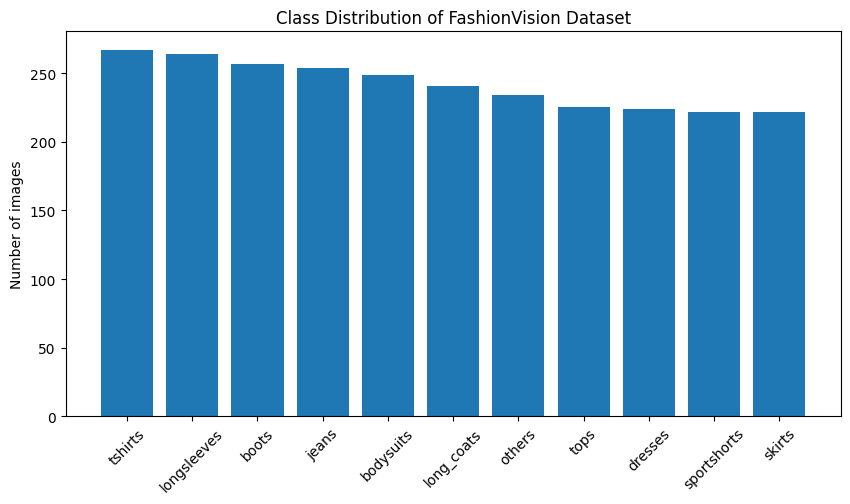

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(df_counts.index, df_counts["image_count"])
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Class Distribution of FashionVision Dataset")
plt.show()


### Visual Inspection of Sample Images

For image datasets, visual inspection is essential. We randomly display a few images from each category to verify label correctness and image quality.

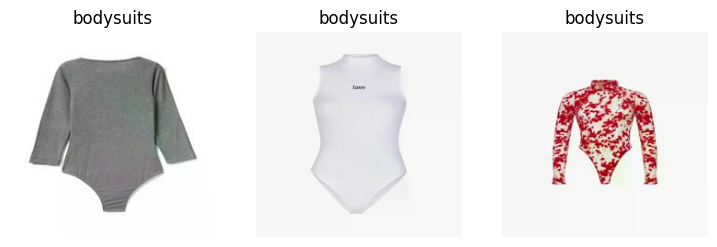

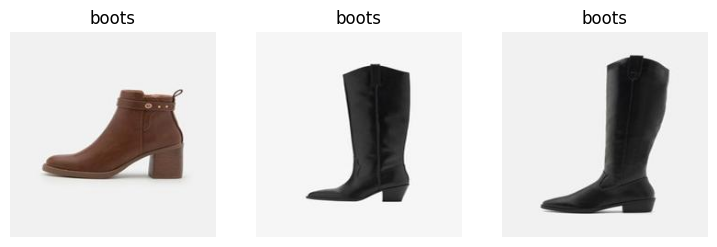

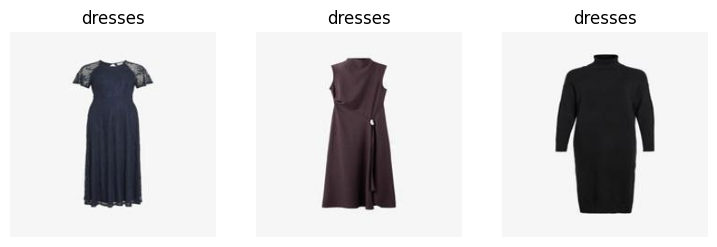

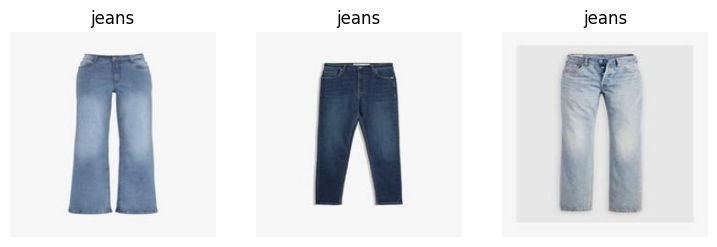

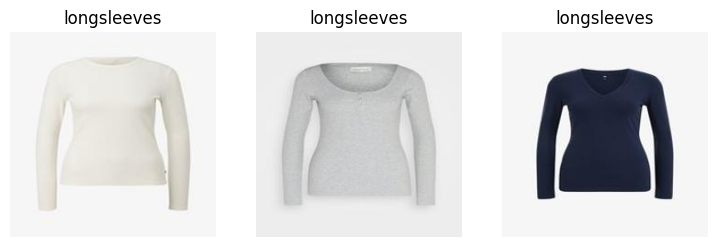

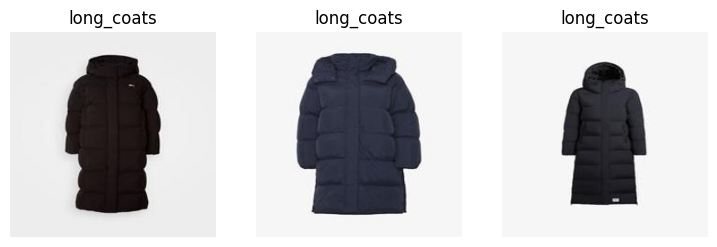

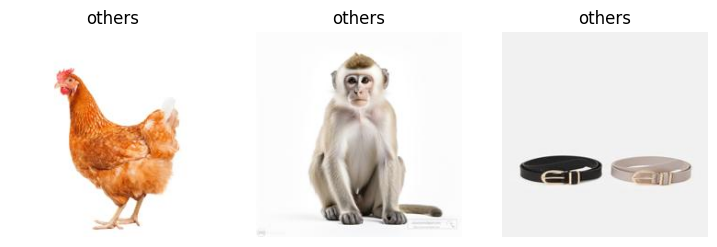

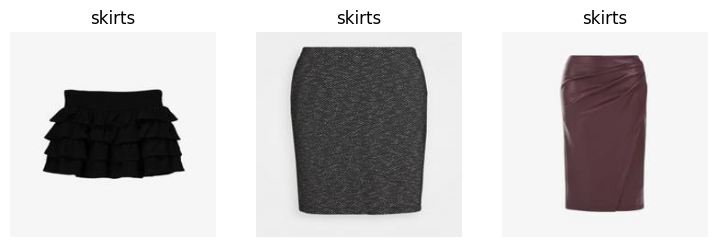

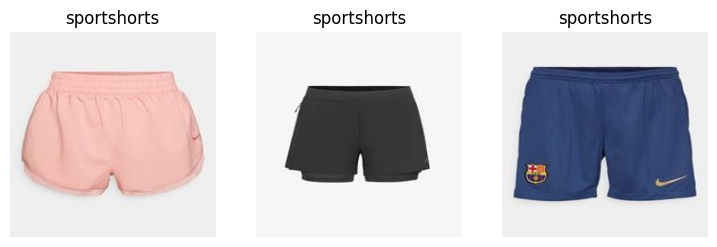

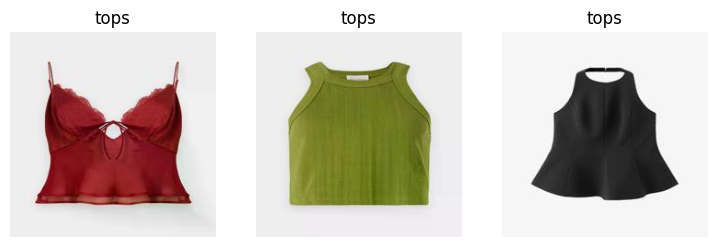

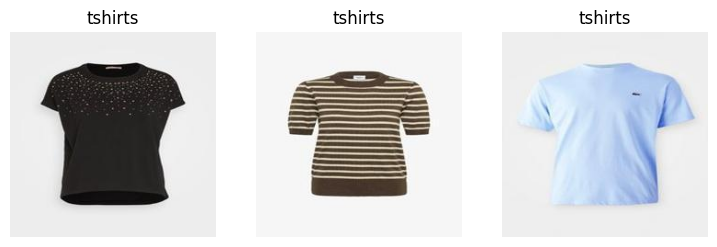

In [78]:
import random
from PIL import Image

def show_sample_images(category, n=3):
    category_path = os.path.join(DATASET_DIR, category)
    images = random.sample(os.listdir(category_path), n)

    plt.figure(figsize=(n * 3, 3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)

    plt.show()

for category in categories:
    show_sample_images(category, n=3)


**EDA insight:**

This confirms that:

- Images are packshots (single product)

- Backgrounds are mostly clean

- Images match their assigned category

### Image Size and Format Consistency

We check whether all images share the same size and color mode after preprocessing.

In [55]:
sizes = set()
modes = set()

for category in categories:
    category_path = os.path.join(DATASET_DIR, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = Image.open(img_path)
        sizes.add(img.size)
        modes.add(img.mode)

print("Unique image sizes:", sizes)
print("Image color modes:", modes)


Unique image sizes: {(224, 224)}
Image color modes: {'RGB'}


**EDA insight:**

All images are:

- The same size (224×224)

- In RGB format

This ensures compatibility with CNN and ViT models.

### Corrupted or Unreadable Images Check

Scraped datasets often contain corrupted files. We explicitly test whether any images cannot be opened.

In [56]:
corrupted = []

for category in categories:
    category_path = os.path.join(DATASET_DIR, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        try:
            Image.open(img_path).verify()
        except:
            corrupted.append(img_path)

print("Corrupted images found:", len(corrupted))


Corrupted images found: 0


### Summary of EDA Findings

Based on the exploratory analysis:

- The dataset is correctly structured for supervised image classification.

- Images are organized by category and visually match their labels.

- Manual data cleaning successfully removed non-packshots, incorrect labels, and multi-product images.

- Image sizes and color modes are consistent after preprocessing.

- Some categories contain fewer images than others, which may require data augmentation or additional scraping.

- No corrupted images were detected.

## Train / Validation / Test Split

After completing data cleaning and image standardization, the dataset was split into three separate subsets: **training**, **validation**, and **test**. This step is essential to evaluate the model fairly and to prevent data leakage.

The dataset was divided using the following ratios:
- 70% of the images were used for training
- 15% were used for validation
- 15% were reserved for final testing

Each category was split independently to ensure that all classes are represented in every subset. The resulting directory structure follows a standard format with separate `train`, `val`, and `test` folders, each containing one subfolder per clothing category.

This setup allows the training set to be used for learning model parameters, the validation set for tuning hyperparameters and preventing overfitting, and the test set for an unbiased evaluation of the final model’s performance.


In [1]:
import os
import shutil
import random

SOURCE_DIR = "fashion_vision/v3_zalando"
OUTPUT_DIR = "fashion_vision/dataset_split"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)


for split in ["train", "val", "test"]:
    for category in os.listdir(SOURCE_DIR):
        os.makedirs(
            os.path.join(OUTPUT_DIR, split, category),
            exist_ok=True
        )

# SPLIT DATA
for category in os.listdir(SOURCE_DIR):
    category_path = os.path.join(SOURCE_DIR, category)

    if not os.path.isdir(category_path):
        continue

    images = os.listdir(category_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy(
            os.path.join(category_path, img),
            os.path.join(OUTPUT_DIR, "train", category, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(category_path, img),
            os.path.join(OUTPUT_DIR, "val", category, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(category_path, img),
            os.path.join(OUTPUT_DIR, "test", category, img)
        )

    print(
        f"{category}: "
        f"train={len(train_images)}, "
        f"val={len(val_images)}, "
        f"test={len(test_images)}"
    )

print("\nDataset split completed.")


bodysuits: train=172, val=37, test=38
boots: train=172, val=37, test=38
dresses: train=156, val=33, test=34
jeans: train=177, val=38, test=39
longsleeves: train=168, val=36, test=36
long_coats: train=168, val=36, test=36
others: train=163, val=35, test=36
skirts: train=153, val=32, test=34
sportshorts: train=154, val=33, test=34
tops: train=149, val=31, test=33
tshirts: train=175, val=37, test=38

Dataset split completed.


## Build the Data Pipeline + Train a Baseline Model 

Now that the dataset has been cleaned, resized to 224×224, and split into train/validation/test folders, the next step is to build a training pipeline and train a first baseline model.

In this section, I load the images directly from the folder structure, apply preprocessing and data augmentation, and train a transfer learning model using a pre-trained CNN backbone. The validation set is used to monitor overfitting and tune the model, while the test set is kept untouched for the final evaluation.

This baseline model provides an initial performance reference that can later be improved using stronger architectures (Vision Transformers), additional data, and better imbalance handling.


In [ ]:
import os
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR = "fashion_vision/dataset_split"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

#BASELINE MODEL (ResNet50)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False 

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")



y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

print("\nConfusion Matrix:")
print(cm)

print("\nClass order:")
for i, name in enumerate(class_names):
    print(i, "=", name)


Found 1807 files belonging to 11 classes.
Found 385 files belonging to 11 classes.
Found 396 files belonging to 11 classes.
Classes: ['bodysuits', 'boots', 'dresses', 'jeans', 'long_coats', 'longsleeves', 'others', 'skirts', 'sportshorts', 'tops', 'tshirts']
Number of classes: 11


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 11)        │     22,539 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,610,251 (90.07 MB)

 Trainable params: 22,539 (88.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6375 - loss: 1.1677 - val_accuracy: 0.8961 - val_loss: 0.3696
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 54s 945ms/step - accuracy: 0.8810 - loss: 0.3978 - val_accuracy: 0.9195 - val_loss: 0.2417
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 52s 907ms/step - accuracy: 0.9098 - loss: 0.2959 - val_accuracy: 0.9532 - val_loss: 0.1911
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 54s 959ms/step - accuracy: 0.9408 - loss: 0.2177 - val_accuracy: 0.9506 - val_loss: 0.1673
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 53s 927ms/step - accuracy: 0.9524 - loss: 0.1778 - val_accuracy: 0.9662 - val_loss: 0.1444
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 55s 962ms/step - accuracy: 0.9579 - loss: 0.1491 - val_accuracy: 0.9610 - val_loss: 0.1359
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 55s 965ms/step - accuracy: 0.9646 - loss: 0.1386 - val_accuracy: 0.9610 - val_loss: 0.1397
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 56s 981ms/step - accuracy: 0.9646 - loss: 0.1207 - val_accurac

### Model Training Results and Evaluation

This section summarizes the results obtained from training and evaluating the baseline image classification model for the FashionVision project.

The classes used in the classification task are:
**bodysuits, boots, dresses, jeans, long_coats, longsleeves, skirts, sportshorts, others, tops, and tshirts**.

#### Model Architecture
A **ResNet50** model pre-trained on **ImageNet** was used as the backbone. Transfer learning was applied by freezing all convolutional layers and training only a newly added classification head.


#### Training Performance
The model converged quickly and showed strong learning behavior:

- **Training accuracy** increased steadily from **~69.7%** in the first epoch to **~96–97%** in later epochs.
- **Validation accuracy** reached **~95%**, indicating good generalization.
- Validation loss decreased consistently, with no severe signs of overfitting thanks to data augmentation and early stopping.

This confirms that the cleaned, packshot-based dataset provides high-quality visual signals for classification.

#### Confusion Matrix Insights
The confusion matrix shows that:
- Most classes are classified correctly with very few misclassifications.
- Errors mainly occur between visually similar categories (e.g., tops vs. longsleeves or bodysuits).
- Minority classes such as **bodysuits** show slightly more confusion, which is expected due to their smaller sample size.

Overall, the confusion matrix confirms strong class separation and balanced performance across most categories.

#### Conclusion
The baseline ResNet50 transfer learning model achieves **high accuracy and stable generalization**, validating both the data collection strategy (clean packshots) and the preprocessing pipeline. This model serves as a strong reference point for future improvements, such as:


These results indicate that FashionVision is well-positioned for further experimentation and performance optimization.


## Evaluation - Iteration 1

In this phase, the FashionVision dataset and modeling approach were significantly improved based on insights gathered from the literature review and documented in the research report. The initial dataset was expanded by introducing **pagination during scraping**, which allowed the collection of images from multiple pages per category instead of relying only on the first category page. This resulted in a larger and more diverse dataset, improving class coverage and reducing sampling bias.

After data collection, the dataset was **manually cleaned** to ensure high quality. Images that were not true packshots, contained multiple products, showed extreme close-ups, or were incorrectly categorized were removed. This step directly follows best practices highlighted in the research, which emphasize that data quality is critical when working with scraped e-commerce images.

To align the dataset with state-of-the-art deep learning models discussed in the research report, all images were **resized to a fixed resolution of 224×224 pixels** and converted to a consistent RGB color format. This standardization step ensures compatibility with pre-trained CNN architectures such as ResNet and stabilizes the training process by providing uniform input dimensions.

In addition to improving the dataset, the **training approach was updated**. A transfer learning strategy was applied using a pre-trained **ResNet50** model, replacing earlier experimental setups. The convolutional backbone was frozen, and a new classification head was trained on the FashionVision dataset. This change reflects recommendations from the literature, which show that transfer learning is highly effective for fashion image classification, especially when working with domain-specific but moderately sized datasets.

Overall, these improvements—dataset expansion through pagination, rigorous manual cleaning, standardized resizing, and an updated transfer learning model—resulted in a more robust experimental setup and substantially improved classification performance.


### Creating the **Others** Category

To improve the FashionVision model, I added an extra class called **`others`**.  
This class contains images that are **not clothing**, which helps the model learn the difference between fashion items and unrelated objects.

#### What I Added

**1. Accessories (from Zalando)**  
I scraped packshot-style images of accessories such as:
- bags  
- belts  
- hats  
- jewellery  


**2. Random Objects (Cars & Animals)**  
To make the others class more diverse I also added:
- car images  
- animal images  

Only images with **one clear object per image** were selected. This avoids noisy scenes and helps the model clearly recognize non-fashion items.

In [ ]:
import os
import time
import urllib.request
import random

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import TimeoutException, StaleElementReferenceException
from webdriver_manager.chrome import ChromeDriverManager



BASE_DIR = os.path.join("fashion_vision", "v3_zalando", "others")
os.makedirs(BASE_DIR, exist_ok=True)

ACCESSORY_TARGET_PER_TYPE = 50
ANIMAL_TARGET = 200

MAX_PAGES = 4
DELAY = 0.6

ZALANDO_ACCESSORIES = {
    "bags": "https://www.zalando.nl/tassen-accessoires-tassen-dames/",
    "belts": "https://www.zalando.nl/tassen-accessoires-riemen-dames/",
    "hats": "https://www.zalando.nl/mutsen-caps-dames/",
    "jewellery": "https://www.zalando.nl/tassen-accessoires-juwelen/"
}

PICSUM_URL = "https://picsum.photos/800/800"


def start_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")

    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )


def accept_cookies(driver):
    time.sleep(3)
    try:
        driver.find_element(
            By.XPATH,
            "//button[contains(text(),'Accepteren') or contains(text(),'Alle cookies')]"
        ).click()
        time.sleep(1)
    except:
        pass

def get_product_links(driver, base_url):
    links = set()

    for page in range(1, MAX_PAGES + 1):
        try:
            driver.get(f"{base_url}?p={page}")
            time.sleep(4)
            accept_cookies(driver)

            for _ in range(8):
                driver.execute_script("window.scrollBy(0, 2500)")
                time.sleep(0.7)

            tiles = driver.find_elements(By.CSS_SELECTOR, 'article a[data-card-type="media"]')
            for t in tiles:
                href = t.get_attribute("href")
                if href and href.endswith(".html"):
                    links.add(href)

        except TimeoutException:
            continue

    return list(links)


def scrape_packshot(driver, product_url):
    try:
        driver.get(product_url)
        time.sleep(2)
        driver.execute_script("window.scrollBy(0, 600)")
        time.sleep(1)

        for img in driver.find_elements(By.TAG_NAME, "img"):
            try:
                src = img.get_attribute("src")
                if src and "filter=packshot" in src:
                    return src
            except StaleElementReferenceException:
                continue
    except:
        return None

    return None


def save_image(url, index):
    path = os.path.join(BASE_DIR, f"others_{index}.jpg")
    if os.path.exists(path):
        return False
    try:
        urllib.request.urlretrieve(url, path)
        return True
    except:
        return False


index = len(os.listdir(BASE_DIR))

print("\n SCRAPING ZALANDO ACCESSORIES")

driver = start_driver()

try:
    for name, url in ZALANDO_ACCESSORIES.items():
        print(f"\n→ {name.upper()}")
        saved = 0

        links = get_product_links(driver, url)

        for link in links:
            if saved >= ACCESSORY_TARGET_PER_TYPE:
                break

            packshot = scrape_packshot(driver, link)
            if packshot and save_image(packshot, index):
                index += 1
                saved += 1

            time.sleep(DELAY)

        print(f"Saved {saved} images for {name}")

finally:
    driver.quit()


print("\n DOWNLOADING ANIMAL IMAGES")

animal_saved = 0

while animal_saved < ANIMAL_TARGET:
    if save_image(PICSUM_URL, index):
        index += 1
        animal_saved += 1
        print(f"Animal image {animal_saved}/{ANIMAL_TARGET}")

    time.sleep(random.uniform(0.3, 0.6))


print("\n DONE")
print(f"Total images in 'others': {len(os.listdir(BASE_DIR))}")
print(f"Saved in: {BASE_DIR}")



 SCRAPING ZALANDO ACCESSORIES

→ BAGS
Saved 50 images for bags

→ BELTS
Saved 50 images for belts

→ HATS
Saved 50 images for hats

→ JEWELLERY
Saved 50 images for jewellery

 DOWNLOADING ANIMAL IMAGES
Animal image 1/200
Animal image 2/200
Animal image 3/200
Animal image 4/200
Animal image 5/200
Animal image 6/200
Animal image 7/200
Animal image 8/200
Animal image 9/200
Animal image 10/200
Animal image 11/200
Animal image 12/200
Animal image 13/200
Animal image 14/200
Animal image 15/200
Animal image 16/200
Animal image 17/200
Animal image 18/200
Animal image 19/200
Animal image 20/200
Animal image 21/200
Animal image 22/200
Animal image 23/200
Animal image 24/200
Animal image 25/200
Animal image 26/200
Animal image 27/200
Animal image 28/200
Animal image 29/200
Animal image 30/200
Animal image 31/200
Animal image 32/200
Animal image 33/200
Animal image 34/200
Animal image 35/200
Animal image 36/200
Animal image 37/200
Animal image 38/200
Animal image 39/200
Animal image 40/200
Animal

In [40]:
import os
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR = "fashion_vision/dataset_split"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded


PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE[0] // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
MLP_UNITS = [128, 64]

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

patches = Patches(PATCH_SIZE)(x)
encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

for _ in range(TRANSFORMER_LAYERS):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=PROJECTION_DIM,
        dropout=0.1
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(MLP_UNITS[0], activation="gelu")(x3)
    x3 = layers.Dense(MLP_UNITS[1], activation="gelu")(x3)

    encoded_patches = layers.Add()([x3, x2])

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)
representation = layers.Dropout(0.3)(representation)

outputs = layers.Dense(num_classes, activation="softmax")(representation)

vit_model = keras.Model(inputs, outputs)

vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

test_loss, test_acc = vit_model.evaluate(test_ds)
print(f"\nViT Test Accuracy: {test_acc:.4f}")
print(f"ViT Test Loss: {test_loss:.4f}")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = vit_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

print("\nConfusion Matrix:")
print(cm)

print("\nClass order:")
for i, name in enumerate(class_names):
    print(i, "=", name)


Found 1807 files belonging to 11 classes.
Found 385 files belonging to 11 classes.
Found 396 files belonging to 11 classes.
Classes: ['bodysuits', 'boots', 'dresses', 'jeans', 'long_coats', 'longsleeves', 'others', 'skirts', 'sportshorts', 'tops', 'tshirts']
Number of classes: 11



Model: "functional_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, None, 64)  │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 64)  │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 64)  │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 64)  │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 64)  │          0 │ dense_2[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 64)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None, 64)  │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 728,203 (2.78 MB)

 Trainable params: 728,203 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.0841 - loss: 2.7124 - val_accuracy: 0.1273 - val_loss: 2.3823
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.1256 - loss: 2.5795 - val_accuracy: 0.1740 - val_loss: 2.3697
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.1428 - loss: 2.4642 - val_accuracy: 0.1870 - val_loss: 2.2869
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1727 - loss: 2.3544 - val_accuracy: 0.2468 - val_loss: 2.2034
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.2037 - loss: 2.2741 - val_accuracy: 0.2260 - val_loss: 2.1706
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.2286 - loss: 2.2176 - val_accuracy: 0.2649 - val_loss: 2.0622
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.2313 - loss: 2.1974 - val_accuracy: 0.2675 - val_loss: 2.0776
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 723ms/step - accuracy: 0.2590 - loss: 2.1250 - val_accuracy: 0.2961 - val

#### Vision Transformer (ViT) Results

In addition to the CNN-based model, a Vision Transformer (ViT) was trained to compare different image classification approaches. Unlike the ResNet50 model, which was pre-trained on ImageNet, the Vision Transformer was trained from scratch using only the FashionVision dataset.

Vision Transformers typically require large-scale datasets or pretrained weights to perform well. Since the FashionVision dataset contains a few thousand images across 11 classes, the ViT had to learn low-level visual features such as edges, shapes, and textures without prior knowledge. This explains the lower final accuracy compared to ResNet50.

Despite this limitation, the ViT showed stable and consistent learning with both training and validation accuracy improving steadily over time and reaching approximately 37% validation accuracy. This confirms that the model was learning meaningful patterns, but was limited by dataset size and class complexity.

#### Model Comparison: ResNet50 vs Vision Transformer (ViT)

| Aspect | ResNet50 (CNN) | Vision Transformer (ViT) |
|------|---------------|--------------------------|
| Model type | Convolutional Neural Network | Transformer-based model |
| Pretrained | Yes (ImageNet) | No (trained from scratch) |
| Dataset size suitability | Works well with medium-sized datasets | Performs best with very large datasets |
| Feature learning | Learns local patterns (edges, textures) | Learns global relationships between patches |
| Final validation accuracy | ~95% | ~37% |

##### Key Insight
For the FashionVision dataset, **ResNet50 clearly outperforms the Vision Transformer** because it benefits from pretrained knowledge and requires fewer images to generalize well. 

## Confusion Matrix

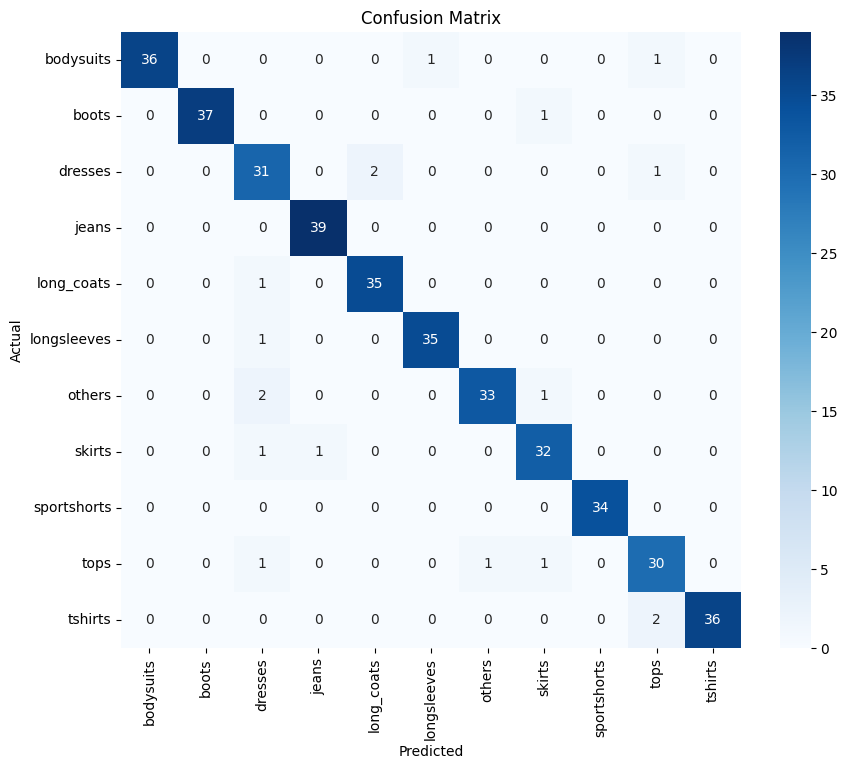

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### Confusion Matrix Summary

- The model performs **very well overall**, with most predictions lying on the diagonal, indicating correct classifications.
- Classes such as **jeans, boots, bodysuits, sports shorts, and t-shirts** show **near-perfect accuracy** with little to no confusion.
- Minor misclassifications occur between **visually similar categories**, for example:
  - *Dresses* are occasionally confused with *long coats*.
  - *Tops* are sometimes misclassified as *others* or *skirts*.
- The **"others"** category shows slightly more confusion, which is expected due to its broad and less-defined nature.


### When the Model May Misclassify Images

Even though the model performs well overall, it can still make mistakes in certain situations. These errors usually happen when the image contains visual challenges that the model was not trained to handle. Below are the most common cases:

#### 1. Images with Multiple Objects
If an image contains more than one clothing item (for example, a dress and boots together), the model may focus on the wrong object.  

**Result:** It predicts the class of the most visible or central item.

#### 2. Complicated or Busy Backgrounds
The model works best with clean product-style images.  
If the background contains furniture, people, or clutter, the model may get confused.

**Result:** Misclassification into visually similar categories.

#### 3. Occlusions or Unusual Poses
If the clothing item is partially hidden, folded, or worn in a non-standard way, the model may not see enough features.  

**Result:** It may guess a different class with a similar shape.

#### 4. Ambiguous or Hybrid Clothing Items
Some fashion items look similar across categories 

**Result:** The model may confuse classes that share similar silhouettes.

#### 5. Unseen or Rare Styles
If the item has a style or design that was not present in the training data, the model may not know how to classify it.  

**Result:** It predicts the closest-looking class.

#### 6. Flipped or Rotated Images

When images are flipped horizontally or vertically, or rotated from their usual orientation, the model may struggle to recognize key features.
This is because most training images were likely in a standard, upright orientation.

**Result:** Reduced accuracy or incorrect class predictions.

#### Summary
The model is strong when the image is clear, simple, and contains one main clothing item.  
It struggles when the image is complex, unclear or contains multiple objects.  


In [6]:
misclassified = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1)
    for i in range(len(labels)):
        if predicted_classes[i] != labels[i]:
            misclassified.append({
                "image": images[i].numpy().astype("uint8"),
                "true_label": class_names[labels[i]],
                "pred_label": class_names[predicted_classes[i]]
            })

print(f"Total misclassified images: {len(misclassified)}")


Total misclassified images: 18


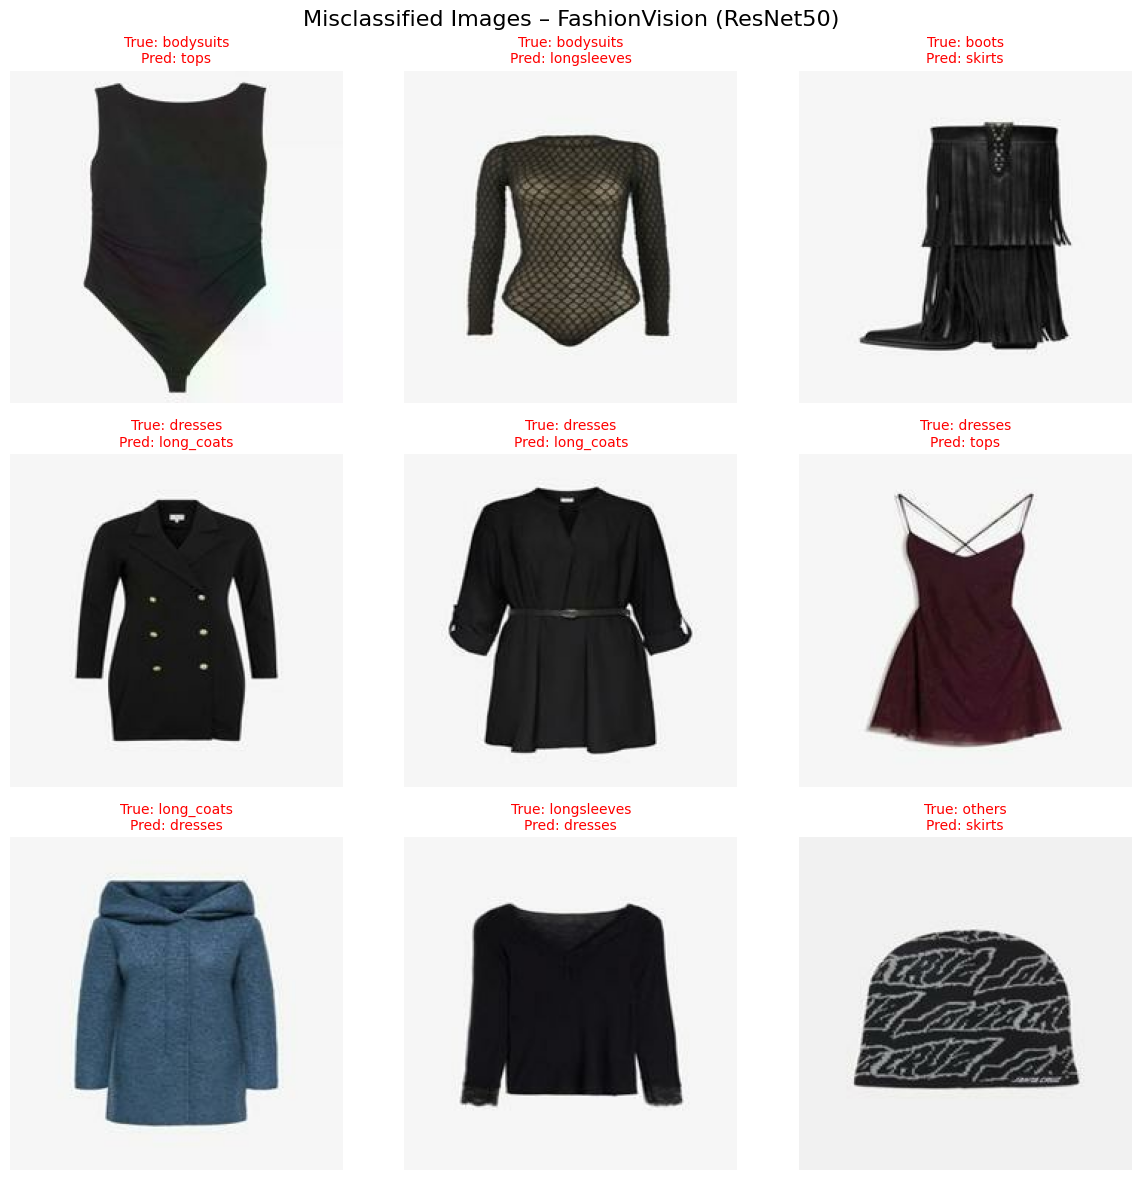

In [ ]:
import matplotlib.pyplot as plt

def show_misclassified(misclassified, max_images=9):
    plt.figure(figsize=(12, 12))

    for i, item in enumerate(misclassified[:max_images]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(item["image"])
        plt.title(
            f"True: {item['true_label']}\nPred: {item['pred_label']}",
            fontsize=10,
            color="red"
        )
        plt.axis("off")

    plt.suptitle("Misclassified Images – FashionVision (ResNet50)", fontsize=16)
    plt.tight_layout()
    plt.show()


show_misclassified(misclassified, max_images=9)


## SHAP

High accuracy scores tell us that the model is working, but they don't explain *how* it's making its decisions. To gain a deeper understanding of the model's logic, I used **SHAP (SHapley Additive exPlanations)**.

#### **Why is SHAP used?**
* **Verification:** It proves the model is identifying actual fashion features (like sleeve length or necklines) rather than just memorizing background colors or lighting.
* **Confidence Check:** It reveals if the model is focusing on the "correct" area ( or if it is being distracted by irrelevant details in the background.

#### **How to Interpret the Visualizations:**
* **Red Pixels:** These areas **increased** the model's confidence in the predicted class. These are the "key features" the model found.
* **Blue Pixels:** These areas **decreased** the model's confidence, acting as evidence against that specific category.
* **The Scale:** The numbers on the color bar show the "weight" of the evidence. Larger numbers indicate that the model found very strong, clear characteristics in that area.


Category: BODYSUITS


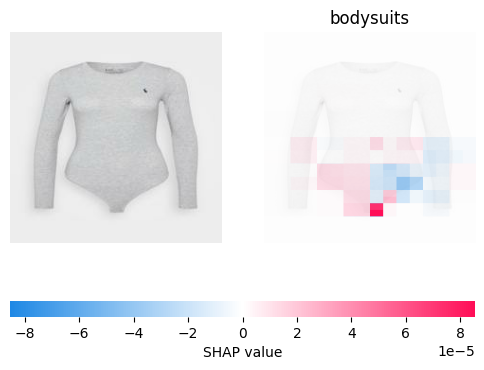


Category: BOOTS


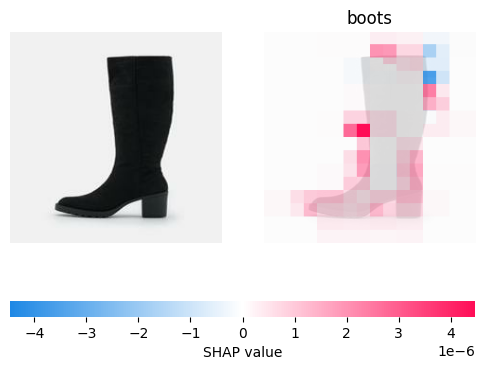


Category: DRESSES


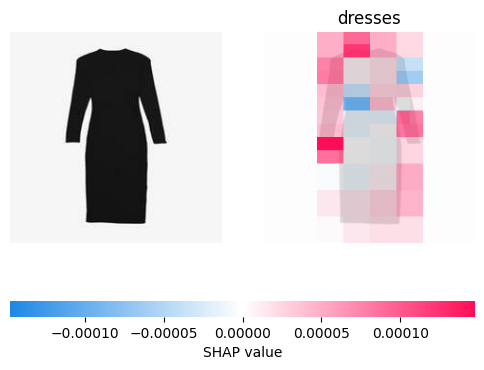


Category: JEANS


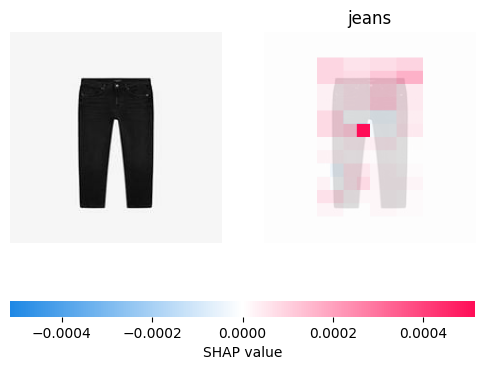


Category: LONG_COATS


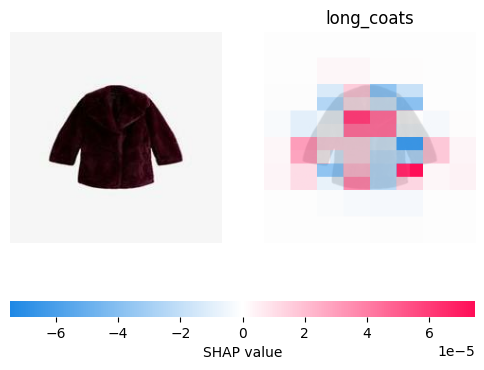


Category: LONGSLEEVES


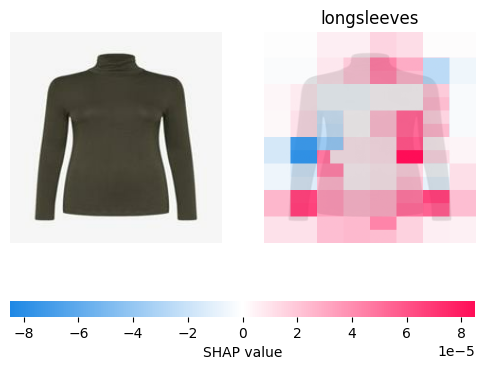


Category: OTHERS


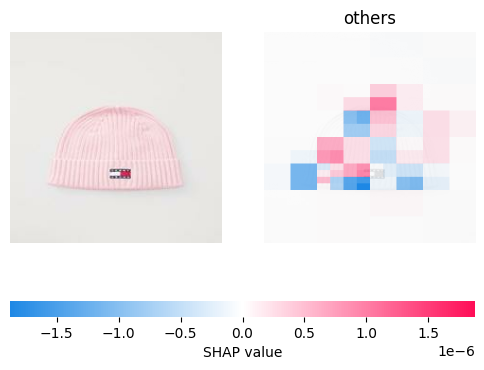


Category: SKIRTS


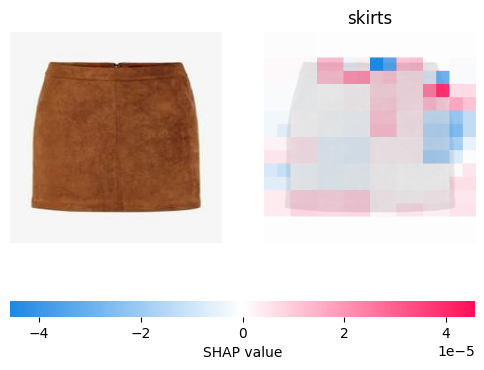


Category: SPORTSHORTS


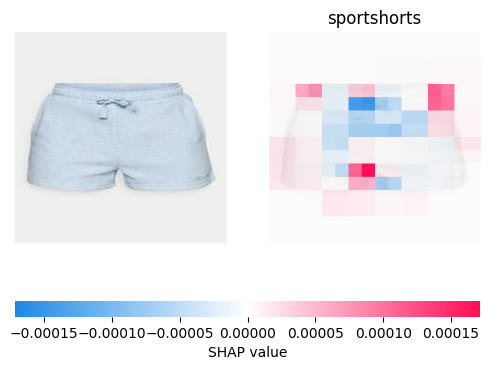


Category: TOPS


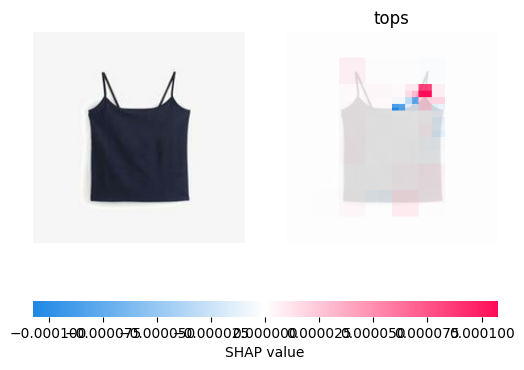


Category: TSHIRTS


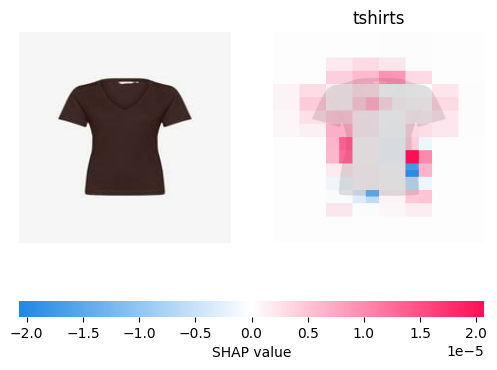

In [36]:
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class_names = ['bodysuits', 'boots', 'dresses', 'jeans', 'long_coats', 
               'longsleeves', 'others', 'skirts', 'sportshorts', 'tops', 'tshirts']


for i in range(len(img_batch)):

    target_class_idx = unique_labels[i]
    target_class_name = class_names[target_class_idx]
    
    print(f"\nCategory: {target_class_name.upper()}")
    
    heatmap = shap_values.values[i, :, :, :, target_class_idx]
    original_pixels = shap_values.data[i].astype(np.uint8)
    
    shap.image_plot(heatmap, original_pixels, labels=[[target_class_name]])

The following table summarizes the key visual features the ResNet50 model prioritizes when classifying fashion items, as identified by the SHAP heatmap analysis:

| Category | Primary Visual Focus Areas |
| :--- | :--- |
| **Bodysuits** | Focuses on the **high-cut leg openings** and the **bottom closure area** to distinguish them from regular tops. |
| **Boots** | Concentrates on the **heel structure** and the **vertical shaft** of the boot. |
| **Dresses** | Looks at the **continuous vertical length** and the absence of a waist seam. |
| **Jeans** | Focuses on the **crotch area** and **waistband/button**. |
| **Long Coats** | Identifies the **collar/lapels** and the **heavy weight/thickness** of the outer fabric. |
| **Longsleeves** | Primarily tracks the **full length of the arms** down to the wrists. |
| **Skirts** | Looks for the **waistline** and the **flared bottom hem** without leg separation. |
| **Sportshorts** | Focuses on the **short leg length** and the **elasticized waistband**. |
| **Tops** | Concentrates on the **neckline** and the **shoulder straps**. |
| **T-shirts** | Identifies the **short sleeve cut** at the mid-bicep and the standard **crew/V-neck** shape. |
| **Others** | Detects the **rounded top** of the headwear. |

#### **SHAP Analysis: Flipped Image Test**

I tested the model with a **flipped image** of a coat to see how orientation affects its logic.

* **Prediction:** The model predicted **Skirt**.
* **Observations:** Because the image is upside down, the model mistook the wide, flared collar of the coat for the bottom hem of a skirt.
* **SHAP Evidence:** The red heatmap confirms the model focused on the flared shape at the top (which it thinks is the bottom).
* **Takeaway:** This proves the model relies on **geometric shapes**, but it also highlights a weakness: the model's accuracy drops when images are not oriented correctly.

<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
C:\Users\svdy0\AppData\Local\Temp\ipykernel_28172\3421800913.py:34: SyntaxWarning: invalid escape sequence '\ '
  print(f"Error: Could not find '{file_name}' in the C:\ folder.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


PartitionExplainer explainer: 2it [00:22, 22.75s/it]               

File found at: C:\test1.jpg
Predicted Category: SKIRTS


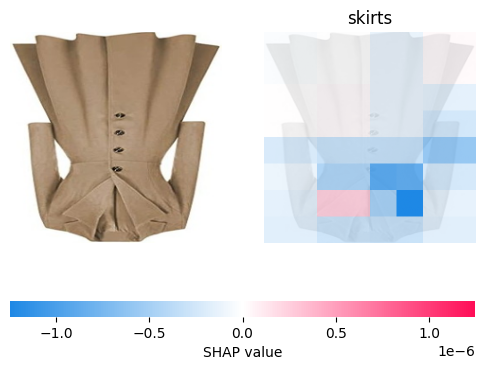

In [43]:
import PIL.Image as Image
import os
import numpy as np

# 1. Path to the image directly on the C drive
file_name = 'test1.jpg'
img_path = os.path.join(r'C:', os.sep, file_name) # Results in C:\test1.jpg

try:
    # 2. Load and Preprocess the image
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = np.array(img) / 255.0             
    img_input = np.expand_dims(img_array, axis=0) 

    # 3. Get prediction and SHAP values
    prediction = model.predict(img_input)
    predicted_class_idx = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_idx]

    # Generate SHAP values for the single image
    test_shap_values = explainer(img_input)

    print(f"File found at: {img_path}")
    print(f"Predicted Category: {predicted_class_name.upper()}")

    # 4. Plot the heatmap
    # We take the values for the predicted class [0, :, :, :, predicted_class_idx]
    heatmap = test_shap_values.values[0, :, :, :, predicted_class_idx]
    original_pixels = (img_input[0] * 255).astype(np.uint8)

    shap.image_plot(heatmap, original_pixels, labels=[[predicted_class_name]])

except FileNotFoundError:
    print(f"Error: Could not find '{file_name}' in the C:\ folder.")
    print("Please check if the file extension is exactly .jpg (not .png or .jpeg).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

## Final Evaluation

The final goal of this project was focused on improving the dataset and testing how the model explains its own decisions.

### 1. Expanding the Dataset and Choosing the Best Model
* **The "Others" Category:** I added a new category for non-clothing items (like bags, hats, cars, animals) to help the model learn the difference between fashion and random objects. This makes the model more reliable for real-world use.
* **Comparing Architectures:** I tested two different ways to build the model. The **ResNet50** was the clear winner with **~95% accuracy**. I also tried a **Vision Transformer (ViT)**, but it only reached **~37%** because these types of models usually need a massive amount of data to perform well from scratch.

### 2. Performance Breakdown (Confusion Matrix)
The confusion matrix shows that the model is very dependable, but it reveals a few interesting patterns:
* **The Strengths:** It is incredibly accurate at identifying **jeans, boots, and bodysuits** because they have very specific shapes.
* **The Challenges:** Small mistakes usually happen between items that look similar, such as a **dress** being called a **long coat**. Since both are long and vertical, it’s a logical mistake for the model to make.



### 3. Understanding the Logic (SHAP Analysis)
I used SHAP heatmaps to see exactly which parts of an image the model looks at before making a guess. This confirmed the model is learning real fashion rules:
* **Targeted Focus:** For **bodysuits**, it looks at the high-cut leg openings. For **long sleeves**, it focuses on the wrists.
* **Confidence Levels:** The model shows much higher confidence (stronger SHAP values) when it sees distinct textures like denim compared to simple, smooth items like beanies.



### 4. Real-World Testing (Streamlit App)
Building a **Streamlit app** allowed me to test the model with "messy" real-world photos. I learned that while the model is powerful, its accuracy can drop if:
* **The background is busy:** Furniture or other people can distract the model's attention.
* **The angle is wrong:** Rotating or flipping an image makes it harder for the model to recognize the standard shapes it was trained on.

### Final Summary
By combining high accuracy with SHAP analysis, I’ve verified that the model has learned to identify the specific design elements that define different types of clothing, making it a reliable tool for fashion classification.